# MODI (ISP) - projekt II, zadanie 28

**Temat:** identyfikacja modeli statycznych i dynamicznych metodą najmniejszych kwadratów.

**Autor:** _uzupełnij_

Notebook jest edytowalnym sprawozdaniem. Komórki kodu uruchamiają istniejące pliki źródłowe Pythona, przeliczają metryki oraz wstawiają wygenerowane wykresy PNG. Po zmianie list stopni/rzędów modeli wystarczy uruchomić notebook ponownie od góry.

## Założenia i metoda

Modele wyznaczono metodą najmniejszych kwadratów bez użycia specjalizowanych bibliotek identyfikacyjnych. Dla macierzy regresorów $\Phi$ i wektora wyjść $y$ parametry modelu spełniają równanie normalne:

$$\Phi^T\Phi\,\theta = \Phi^T y.$$

W implementacji układ normalny jest rozwiązywany własnym solverem eliminacji Gaussa z częściowym wyborem elementu głównego. Dokładność oceniono metrykami:

$$MSE = \frac{1}{N}\sum_{k=1}^{N}(y(k)-\hat{y}(k))^2, \qquad RMSE = \sqrt{MSE}.$$

In [1]:
from pathlib import Path
import html
import importlib.util
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, Markdown, display

# Jeśli notebook zostanie otwarty z innego katalogu, znajdź katalog projektu po folderach z danymi.
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "danestat28").exists() and (candidate / "danedynucz28").exists():
            return candidate
    raise FileNotFoundError("Nie znaleziono katalogu projektu z folderami danych.")

ROOT = find_project_root(Path.cwd().resolve())
STATIC_CODE = ROOT / "indetyfikacja_modeli_statycznych" / "kod"
DYNAMIC_CODE = ROOT / "identyfikacja_modeli_dynamicznych" / "kod"

GENERATE_NOTEBOOK_FIGURES = True

print(f"Katalog projektu: {ROOT}")
print(f"Interpreter kernela: {sys.executable}")

Katalog projektu: C:\Users\mikol\OneDrive\Politechnika\MODI\Projekt2
Interpreter kernela: c:\Users\mikol\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [2]:
def load_module(module_name: str, path: Path):
    """Wczytuje plik .py jako moduł o unikalnej nazwie, aby nie mieszać importów statycznych i dynamicznych."""
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def display_png(relative_path: str, width: int = 900):
    """Wyświetla wygenerowany obrazek PNG albo podaje informację, że trzeba uruchomić generowanie."""
    path = ROOT / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"Brak pliku `{relative_path}`. Uruchom komórkę generującą wykresy."))


def fmt(value, precision: int = 6) -> str:
    if value is None:
        return ""
    if isinstance(value, (float, np.floating)) and not np.isfinite(value):
        return "∞"
    if isinstance(value, (float, np.floating)):
        return f"{value:.{precision}f}"
    return html.escape(str(value))


def show_table(rows: list[dict], columns: list[tuple[str, str]], title: str | None = None,
               highlight_index: int | None = None, precision: int = 6):
    caption = f"<caption>{html.escape(title)}</caption>" if title else ""
    head = "".join(f"<th>{html.escape(label)}</th>" for key, label in columns)
    body = []
    for i, row in enumerate(rows):
        style = " style='background:#e2f0d9'" if i == highlight_index else ""
        cells = "".join(f"<td>{fmt(row.get(key), precision)}</td>" for key, label in columns)
        body.append(f"<tr{style}>{cells}</tr>")
    css = """
    <style>
    table.modi {border-collapse: collapse; font-size: 13px; margin: 8px 0 18px 0;}
    table.modi caption {caption-side: top; text-align: left; font-weight: 700; margin-bottom: 6px;}
    table.modi th, table.modi td {border: 1px solid #c8c8c8; padding: 5px 8px; text-align: right;}
    table.modi th:first-child, table.modi td:first-child {text-align: left;}
    table.modi th {background: #315f8c; color: white;}
    </style>
    """
    display(HTML(css + f"<table class='modi'>{caption}<thead><tr>{head}</tr></thead><tbody>{''.join(body)}</tbody></table>"))

## Uruchomienie kodu źródłowego

Ta komórka wywołuje oba skrypty główne: część statyczną i dynamiczną. Skrypty generują wszystkie wykresy używane dalej w sprawozdaniu. Jeżeli chcesz tylko przejrzeć raport bez ponownego liczenia, ustaw `RUN_MAIN_SCRIPTS = False`.

In [3]:
RUN_MAIN_SCRIPTS = True

def run_project_script(script: Path):
    env = os.environ.copy()
    env["MPLBACKEND"] = "Agg"
    env["PYTHONIOENCODING"] = "utf-8"
    result = subprocess.run(
        [sys.executable, str(script)],
        cwd=str(ROOT),
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=env,
    )
    print(f"\n===== {script.relative_to(ROOT)} =====")
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print("STDERR:\n" + result.stderr)
    result.check_returncode()
    return result

if RUN_MAIN_SCRIPTS:
    run_project_script(STATIC_CODE / "main.py")
    run_project_script(DYNAMIC_CODE / "main.py")
else:
    print("Pominięto ponowne uruchamianie skryptów głównych.")


===== indetyfikacja_modeli_statycznych\kod\main.py =====
Łącznie próbek : 200
Zbiór uczący   : 120 (60 %)
Zbiór weryf.   : 80  (40 %)

Model liniowy:  y(u) = 0.977620 + 1.436710 * u
  Zbiór uczący  (N=120): MSE = 0.897856   RMSE = 0.947552
  Zbiór weryf. (N=80):  MSE = 0.844686   RMSE = 0.919068

── Modele wielomianowe ──────────────────────────────────────
Model wielomianowy N=1:  y(u) = 0.9776  +1.4367·u
  Zbiór uczący  (N=120): MSE = 0.897856   RMSE = 0.947552
  Zbiór weryf. (N=80):  MSE = 0.844686   RMSE = 0.919068

Model wielomianowy N=2:  y(u) = -0.0609  +1.3397·u  +2.5964·u^2
  Zbiór uczący  (N=120): MSE = 0.191942   RMSE = 0.438112
  Zbiór weryf. (N=80):  MSE = 0.207590   RMSE = 0.455620

Model wielomianowy N=3:  y(u) = 0.0253  +3.2363·u  +2.5283·u^2  -2.8524·u^3
  Zbiór uczący  (N=120): MSE = 0.002217   RMSE = 0.047085
  Zbiór weryf. (N=80):  MSE = 0.002472   RMSE = 0.049715

Model wielomianowy N=4:  y(u) = 0.0048  +3.2388·u  +2.7319·u^2  -2.8542·u^3  -0.2293·u^4
  Zbiór uczą

# 1. Identyfikacja modeli statycznych

Dane statyczne podzielono na zbiór uczący i weryfikujący w proporcji 60% do 40%. W pierwszej kolumnie danych znajduje się wejście $u$, a w drugiej wyjście $y$.

In [4]:
static_import = load_module("modi_static_import", STATIC_CODE / "import_danych.py")
static_models = load_module("modi_static_models", STATIC_CODE / "modele.py")
static_plotting = load_module("modi_static_plotting", STATIC_CODE / "rysowanie.py")

STATIC_SPLIT = 0.6
STATIC_POLY_DEGREES = list(range(1, 21))

dane_stat = static_import.Import_Static_Data(split=STATIC_SPLIT)
plotter_stat = static_plotting.PlotData(dane_stat.out_dir)

if GENERATE_NOTEBOOK_FIGURES:
    plotter_stat.plot_all_data(dane_stat.u, dane_stat.y)
    plotter_stat.plot_static_characteristic(dane_stat.u, dane_stat.y)
    plotter_stat.plot_training_data(dane_stat.u_ucz, dane_stat.y_ucz)
    plotter_stat.plot_training_characteristic(dane_stat.u_ucz, dane_stat.y_ucz)
    plotter_stat.plot_verification_data(dane_stat.u_wer, dane_stat.y_wer, dane_stat.N_uczacy)
    plotter_stat.plot_verification_characteristic(dane_stat.u_wer, dane_stat.y_wer)
    plt.close("all")

print(f"Liczba wszystkich próbek: {dane_stat.N}")
print(f"Zbiór uczący: {dane_stat.N_uczacy} próbek ({dane_stat.N_uczacy / dane_stat.N:.0%})")
print(f"Zbiór weryfikujący: {dane_stat.N_weryf} próbek ({dane_stat.N_weryf / dane_stat.N:.0%})")

Liczba wszystkich próbek: 200
Zbiór uczący: 120 próbek (60%)
Zbiór weryfikujący: 80 próbek (40%)


## 1a. Dane statyczne

Poniżej pokazano przebiegi sygnałów oraz charakterystyki statyczne dla wszystkich danych, zbioru uczącego i zbioru weryfikującego.

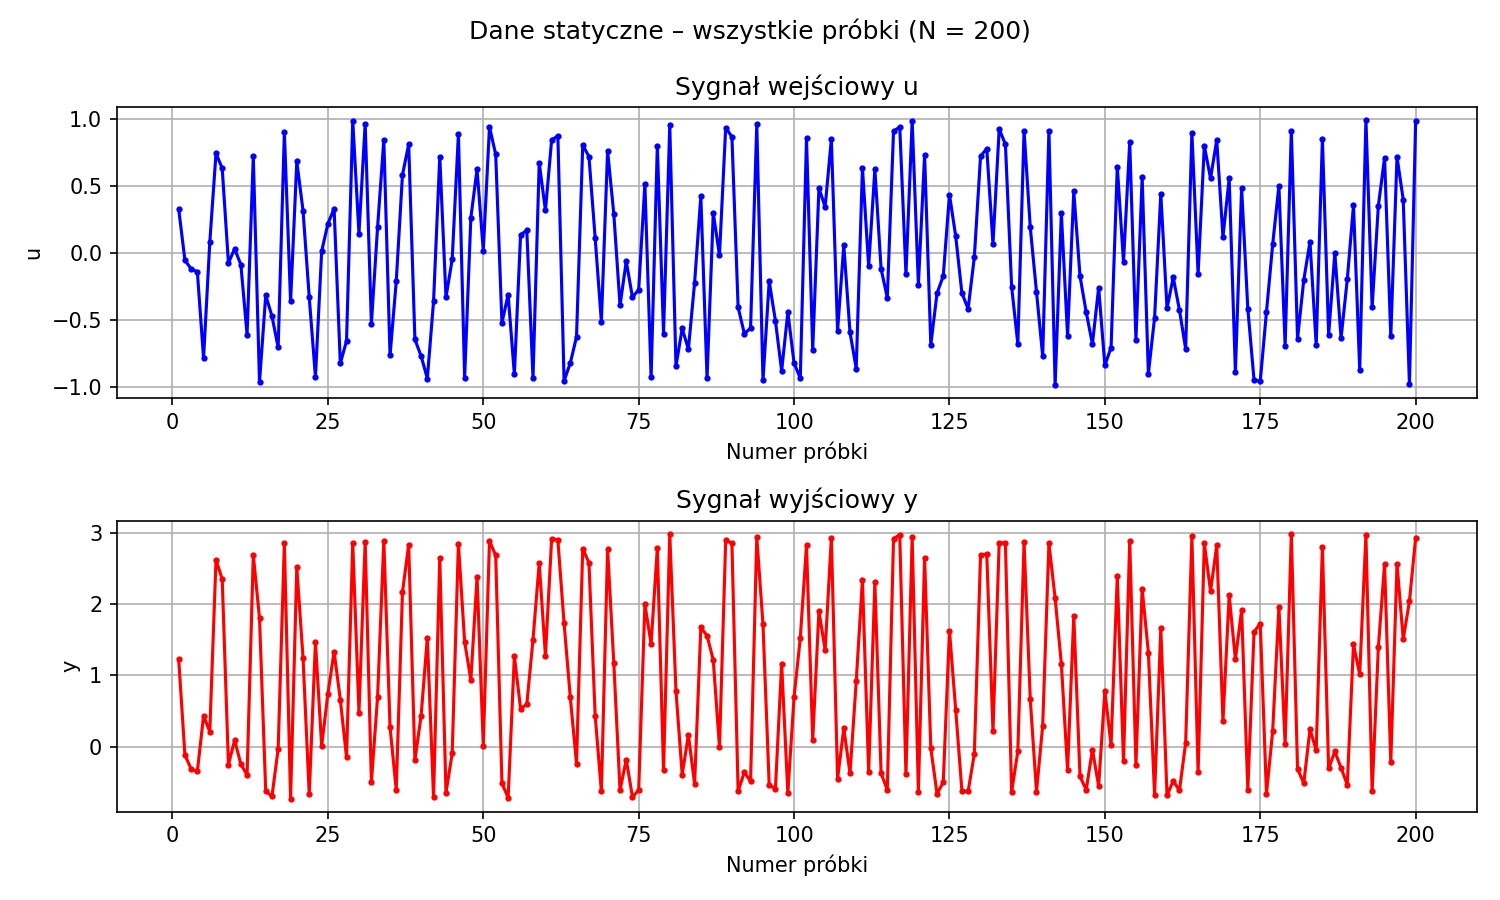

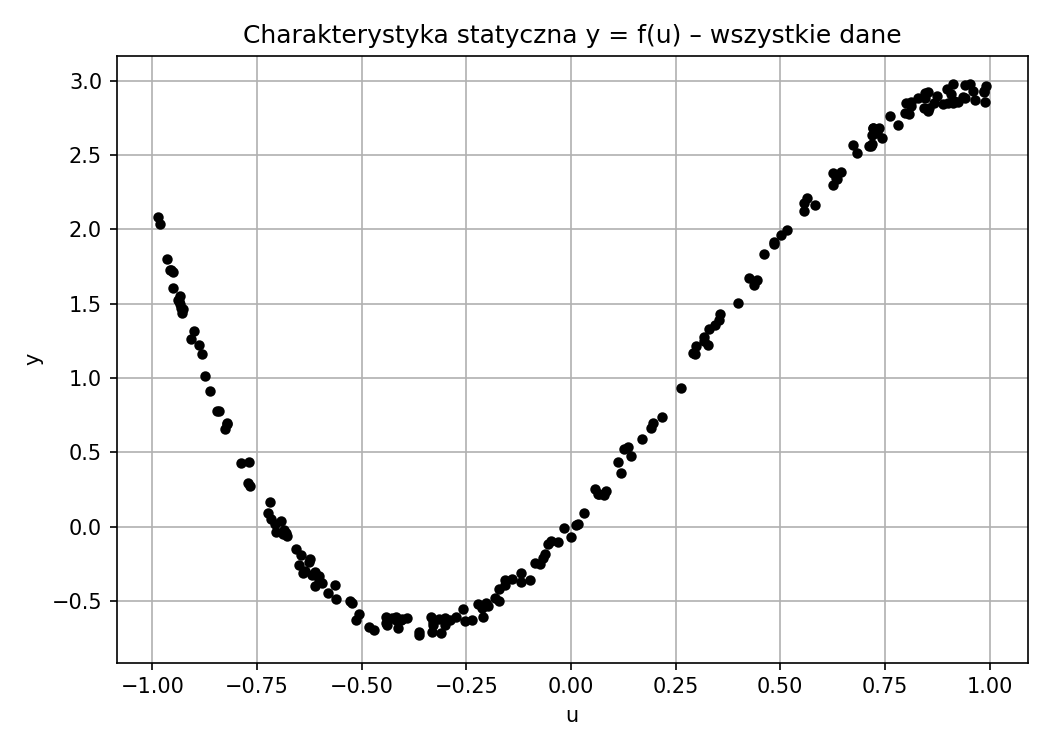

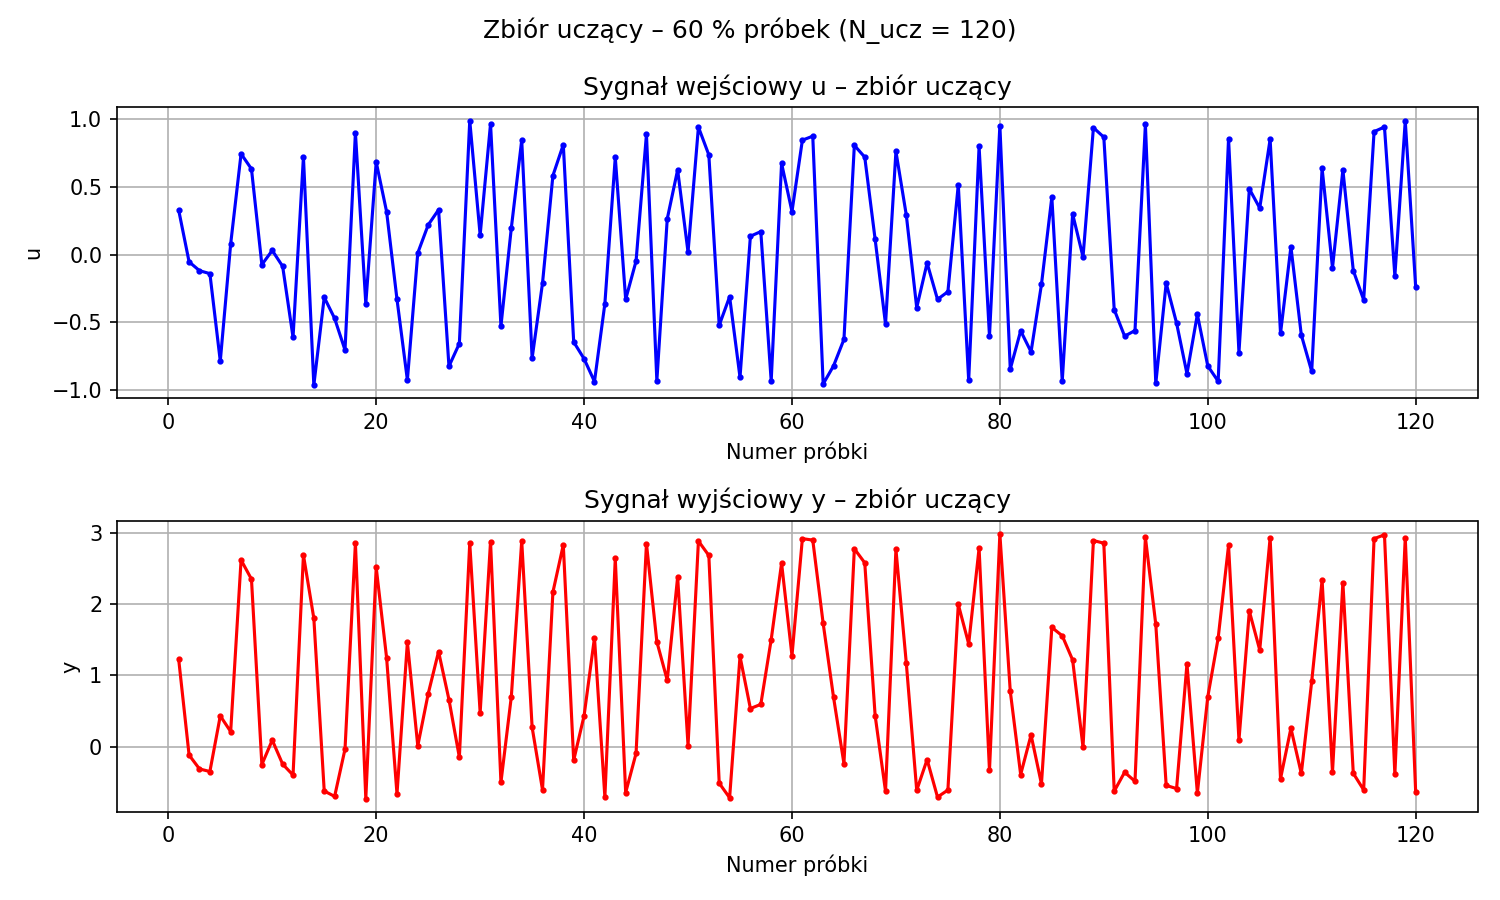

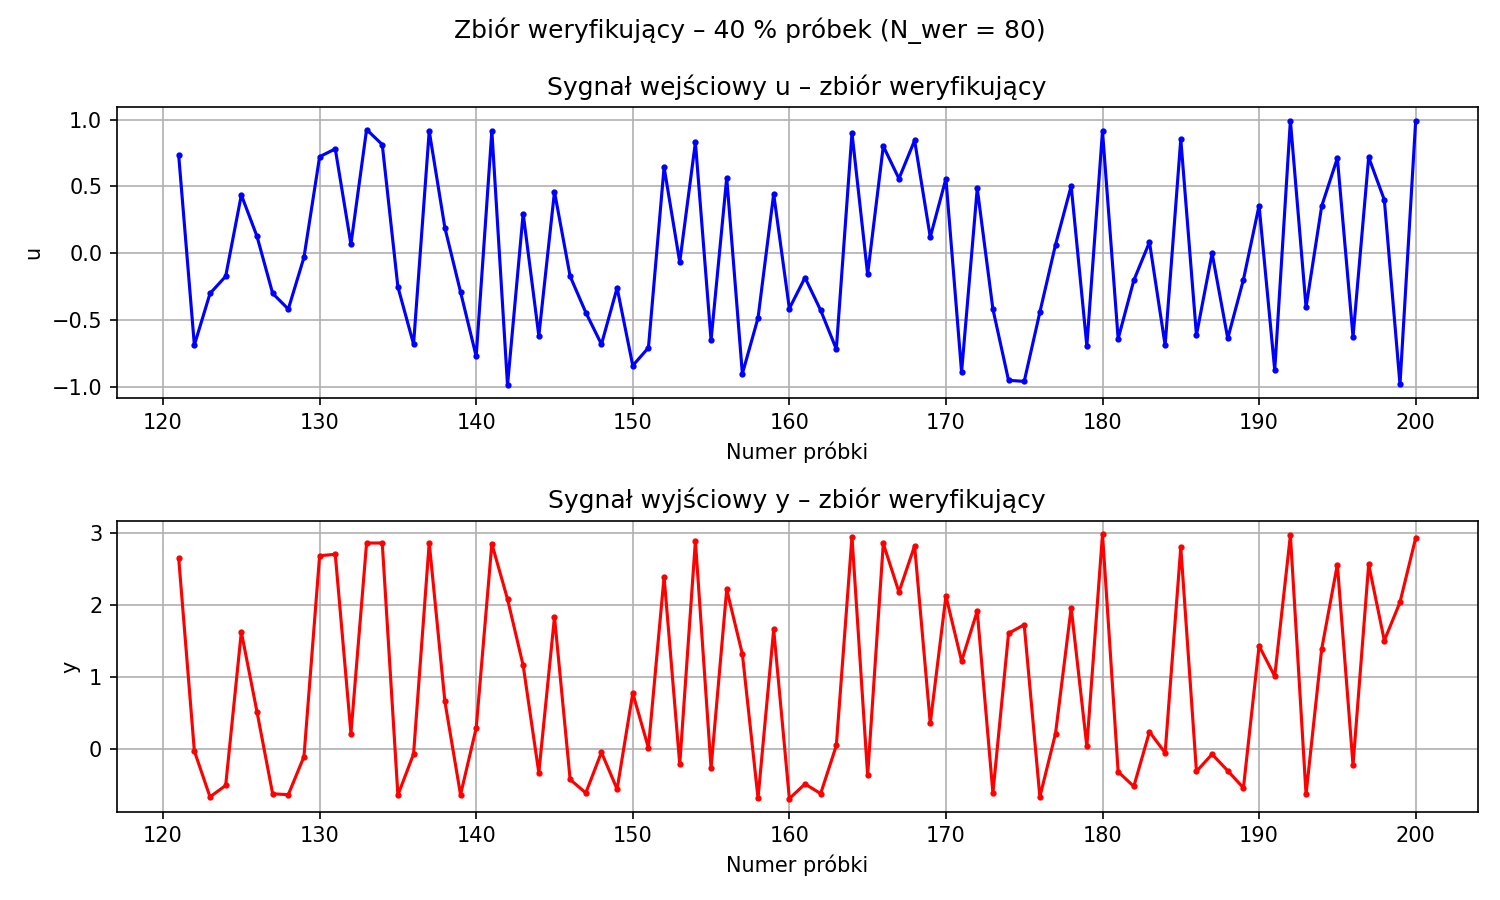

In [5]:
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/dane_surowe/dane_statyczne_wszystkie.png")
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/dane_surowe/charakterystyka_statyczna_wszystkie.png", width=650)
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/dane_surowe/dane_statyczne_uczace.png")
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/dane_surowe/dane_statyczne_weryfikujace.png")

## 1b. Statyczny model liniowy

Rozważany model ma postać:

$$y(u) = a_0 + a_1u.$$

Wektor parametrów $[a_0, a_1]^T$ wyznaczono metodą MNK na zbiorze uczącym, a jakość oceniono osobno dla danych uczących i weryfikujących.

In [6]:
linear_model = static_models.LinearModel().fit(dane_stat.u_ucz, dane_stat.y_ucz)
linear_train = linear_model.evaluate(dane_stat.u_ucz, dane_stat.y_ucz)
linear_ver = linear_model.evaluate(dane_stat.u_wer, dane_stat.y_wer)

linear_rows = [{
    "model": "liniowy N=1",
    "mse_ucz": linear_train["mse"],
    "rmse_ucz": linear_train["rmse"],
    "mse_wer": linear_ver["mse"],
    "rmse_wer": linear_ver["rmse"],
}]

if GENERATE_NOTEBOOK_FIGURES:
    plotter_stat.plot_model_characteristic(dane_stat.u, dane_stat.y, linear_model.a0, linear_model.a1)
    plotter_stat.plot_verification_results(
        dane_stat.y_wer, linear_ver["y_pred"], dane_stat.N_uczacy,
        linear_ver["mse"], linear_ver["rmse"],
    )
    plotter_stat.plot_scatter(dane_stat.y_wer, linear_ver["y_pred"])
    plt.close("all")

display(Markdown(f"Model liniowy: $y(u) = {linear_model.a0:.6f} + {linear_model.a1:.6f}u$"))
show_table(linear_rows, [
    ("model", "Model"), ("mse_ucz", "MSE ucz."), ("rmse_ucz", "RMSE ucz."),
    ("mse_wer", "MSE wer."), ("rmse_wer", "RMSE wer."),
], "Metryki modelu liniowego")

Model liniowy: $y(u) = 0.977620 + 1.436710u$

Model,MSE ucz.,RMSE ucz.,MSE wer.,RMSE wer.
liniowy N=1,0.897856,0.947552,0.844686,0.919068


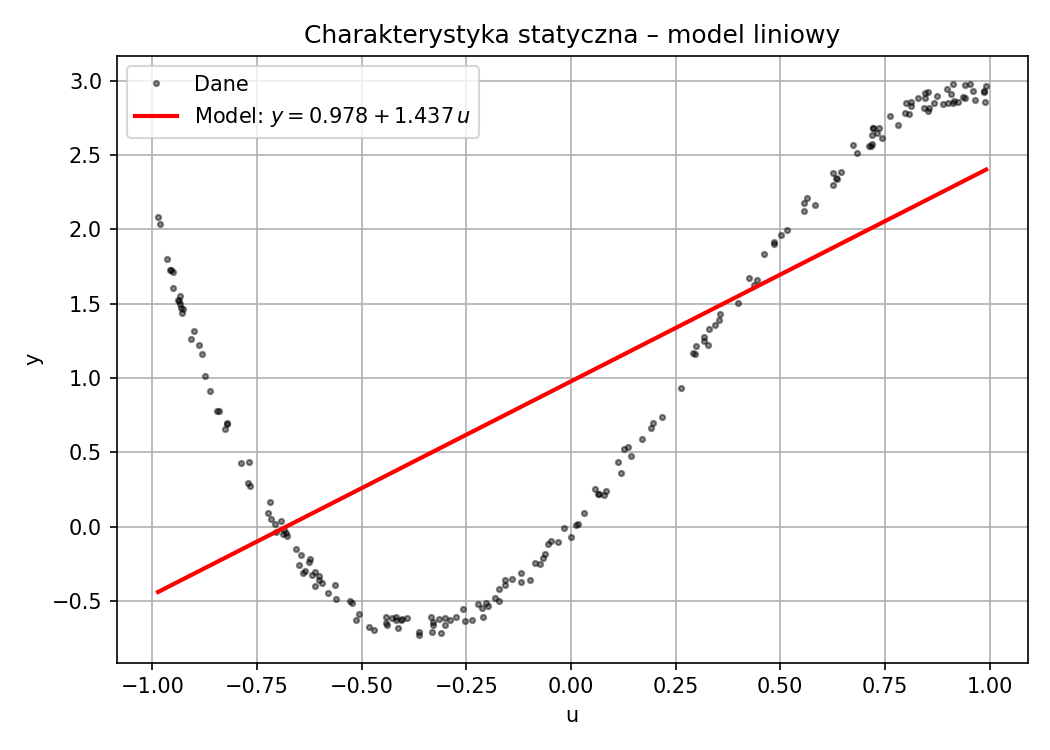

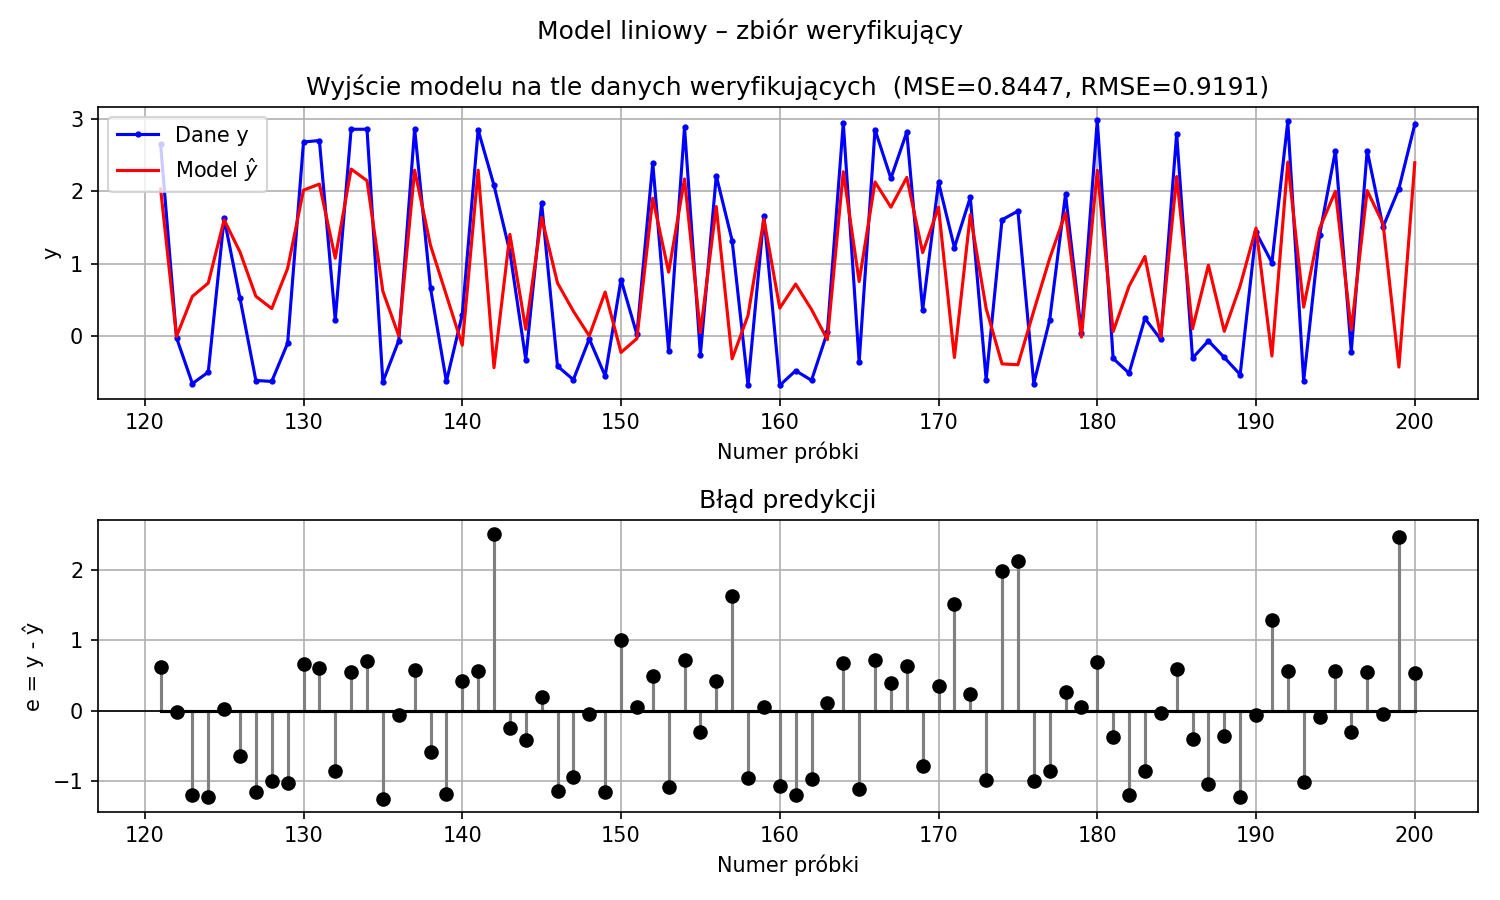

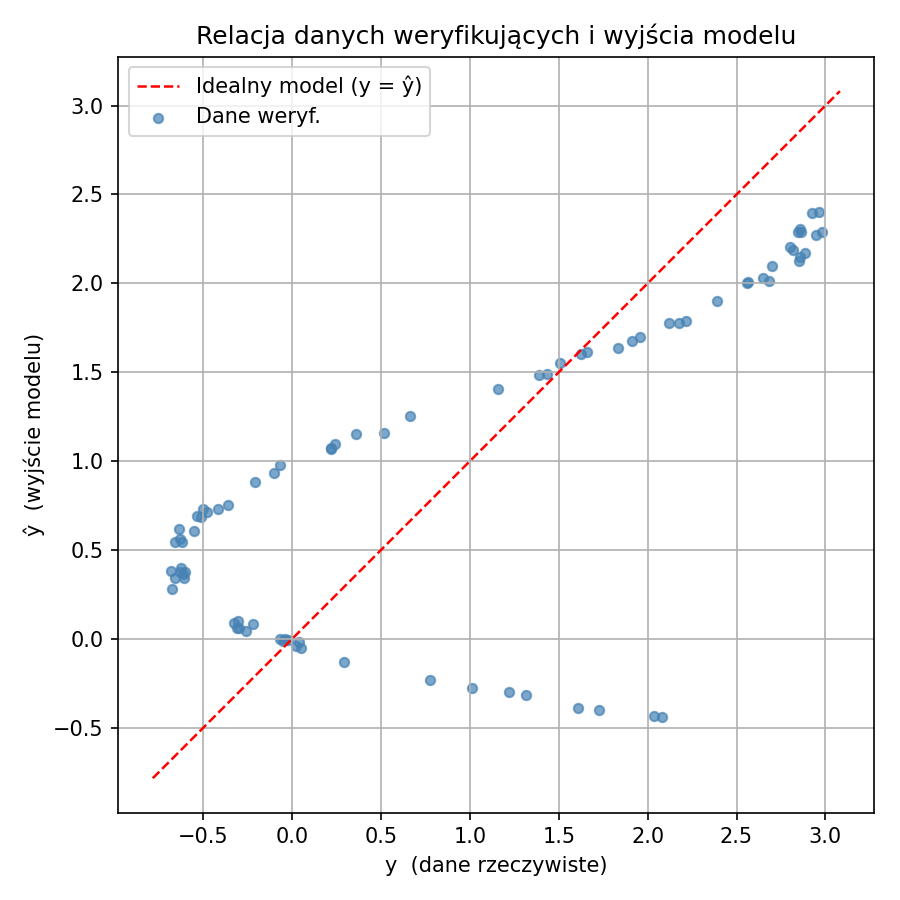

In [7]:
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_liniowy/model_liniowy_charakterystyka.png", width=700)
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_liniowy/model_liniowy_weryfikacja_przebieg.png")
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_liniowy/model_liniowy_weryfikacja_scatter.png", width=620)

**Komentarz:** model liniowy stanowi punkt odniesienia. Jeżeli rozrzut punktów na wykresie $y$ względem $\hat{y}$ jest systematycznie zakrzywiony, oznacza to, że sama zależność liniowa nie opisuje wystarczająco nieliniowej charakterystyki statycznej.

## 1c. Statyczne modele wielomianowe

Testowany model wielomianowy ma postać:

$$y(u)=a_0+\sum_{i=1}^{N}a_i u^i.$$

Stopnie wielomianu można edytować w zmiennej `STATIC_POLY_DEGREES` powyżej. Najlepszy model wybieramy na podstawie najmniejszego błędu na zbiorze weryfikującym, zwracając uwagę na ryzyko przeuczenia przy wysokich stopniach.

In [8]:
poly_results = []
poly_models = {}
for degree in STATIC_POLY_DEGREES:
    model = static_models.PolynomialModel(degree=degree).fit(dane_stat.u_ucz, dane_stat.y_ucz)
    train = model.evaluate(dane_stat.u_ucz, dane_stat.y_ucz)
    ver = model.evaluate(dane_stat.u_wer, dane_stat.y_wer)
    poly_models[degree] = model
    if GENERATE_NOTEBOOK_FIGURES:
        plotter_stat.plot_poly_characteristic(dane_stat.u, dane_stat.y, model, degree)
        plotter_stat.plot_poly_verification_results(
            dane_stat.y_wer, ver["y_pred"], dane_stat.N_uczacy,
            ver["mse"], ver["rmse"], degree,
        )
        plotter_stat.plot_poly_scatter(dane_stat.y_wer, ver["y_pred"], degree)
    poly_results.append({
        "degree": degree,
        "params": degree + 1,
        "mse_ucz": train["mse"],
        "rmse_ucz": train["rmse"],
        "mse_wer": ver["mse"],
        "rmse_wer": ver["rmse"],
    })

if GENERATE_NOTEBOOK_FIGURES:
    plotter_stat.plot_metrics_table(poly_results)
    plotter_stat.plot_all_poly_characteristics(
        dane_stat.u, dane_stat.y,
        [poly_models[d] for d in STATIC_POLY_DEGREES], STATIC_POLY_DEGREES,
    )
    plt.close("all")

best_poly_index = min(range(len(poly_results)), key=lambda i: poly_results[i]["mse_wer"])
best_poly = poly_results[best_poly_index]

show_table(poly_results, [
    ("degree", "N"), ("params", "L. par."), ("mse_ucz", "MSE ucz."), ("rmse_ucz", "RMSE ucz."),
    ("mse_wer", "MSE wer."), ("rmse_wer", "RMSE wer."),
], "Metryki statycznych modeli wielomianowych", highlight_index=best_poly_index)

display(Markdown(
    f"Najniższy błąd weryfikacji uzyskano dla modelu wielomianowego **N={best_poly['degree']}** "
    f"(MSE={best_poly['mse_wer']:.6f}, RMSE={best_poly['rmse_wer']:.6f})."
))

N,L. par.,MSE ucz.,RMSE ucz.,MSE wer.,RMSE wer.
1,2,0.897856,0.947552,0.844686,0.919068
2,3,0.191942,0.438112,0.207590,0.455620
3,4,0.002217,0.047085,0.002472,0.049715
4,5,0.001903,0.043619,0.002290,0.047859
5,6,0.001899,0.043574,0.002318,0.048142
6,7,0.001896,0.043547,0.002273,0.047674
7,8,0.001869,0.043236,0.002271,0.047651
8,9,0.001868,0.043218,0.002282,0.047766
9,10,0.001865,0.043186,0.002270,0.047648
10,11,0.001848,0.042987,0.002167,0.046549


Najniższy błąd weryfikacji uzyskano dla modelu wielomianowego **N=10** (MSE=0.002167, RMSE=0.046549).

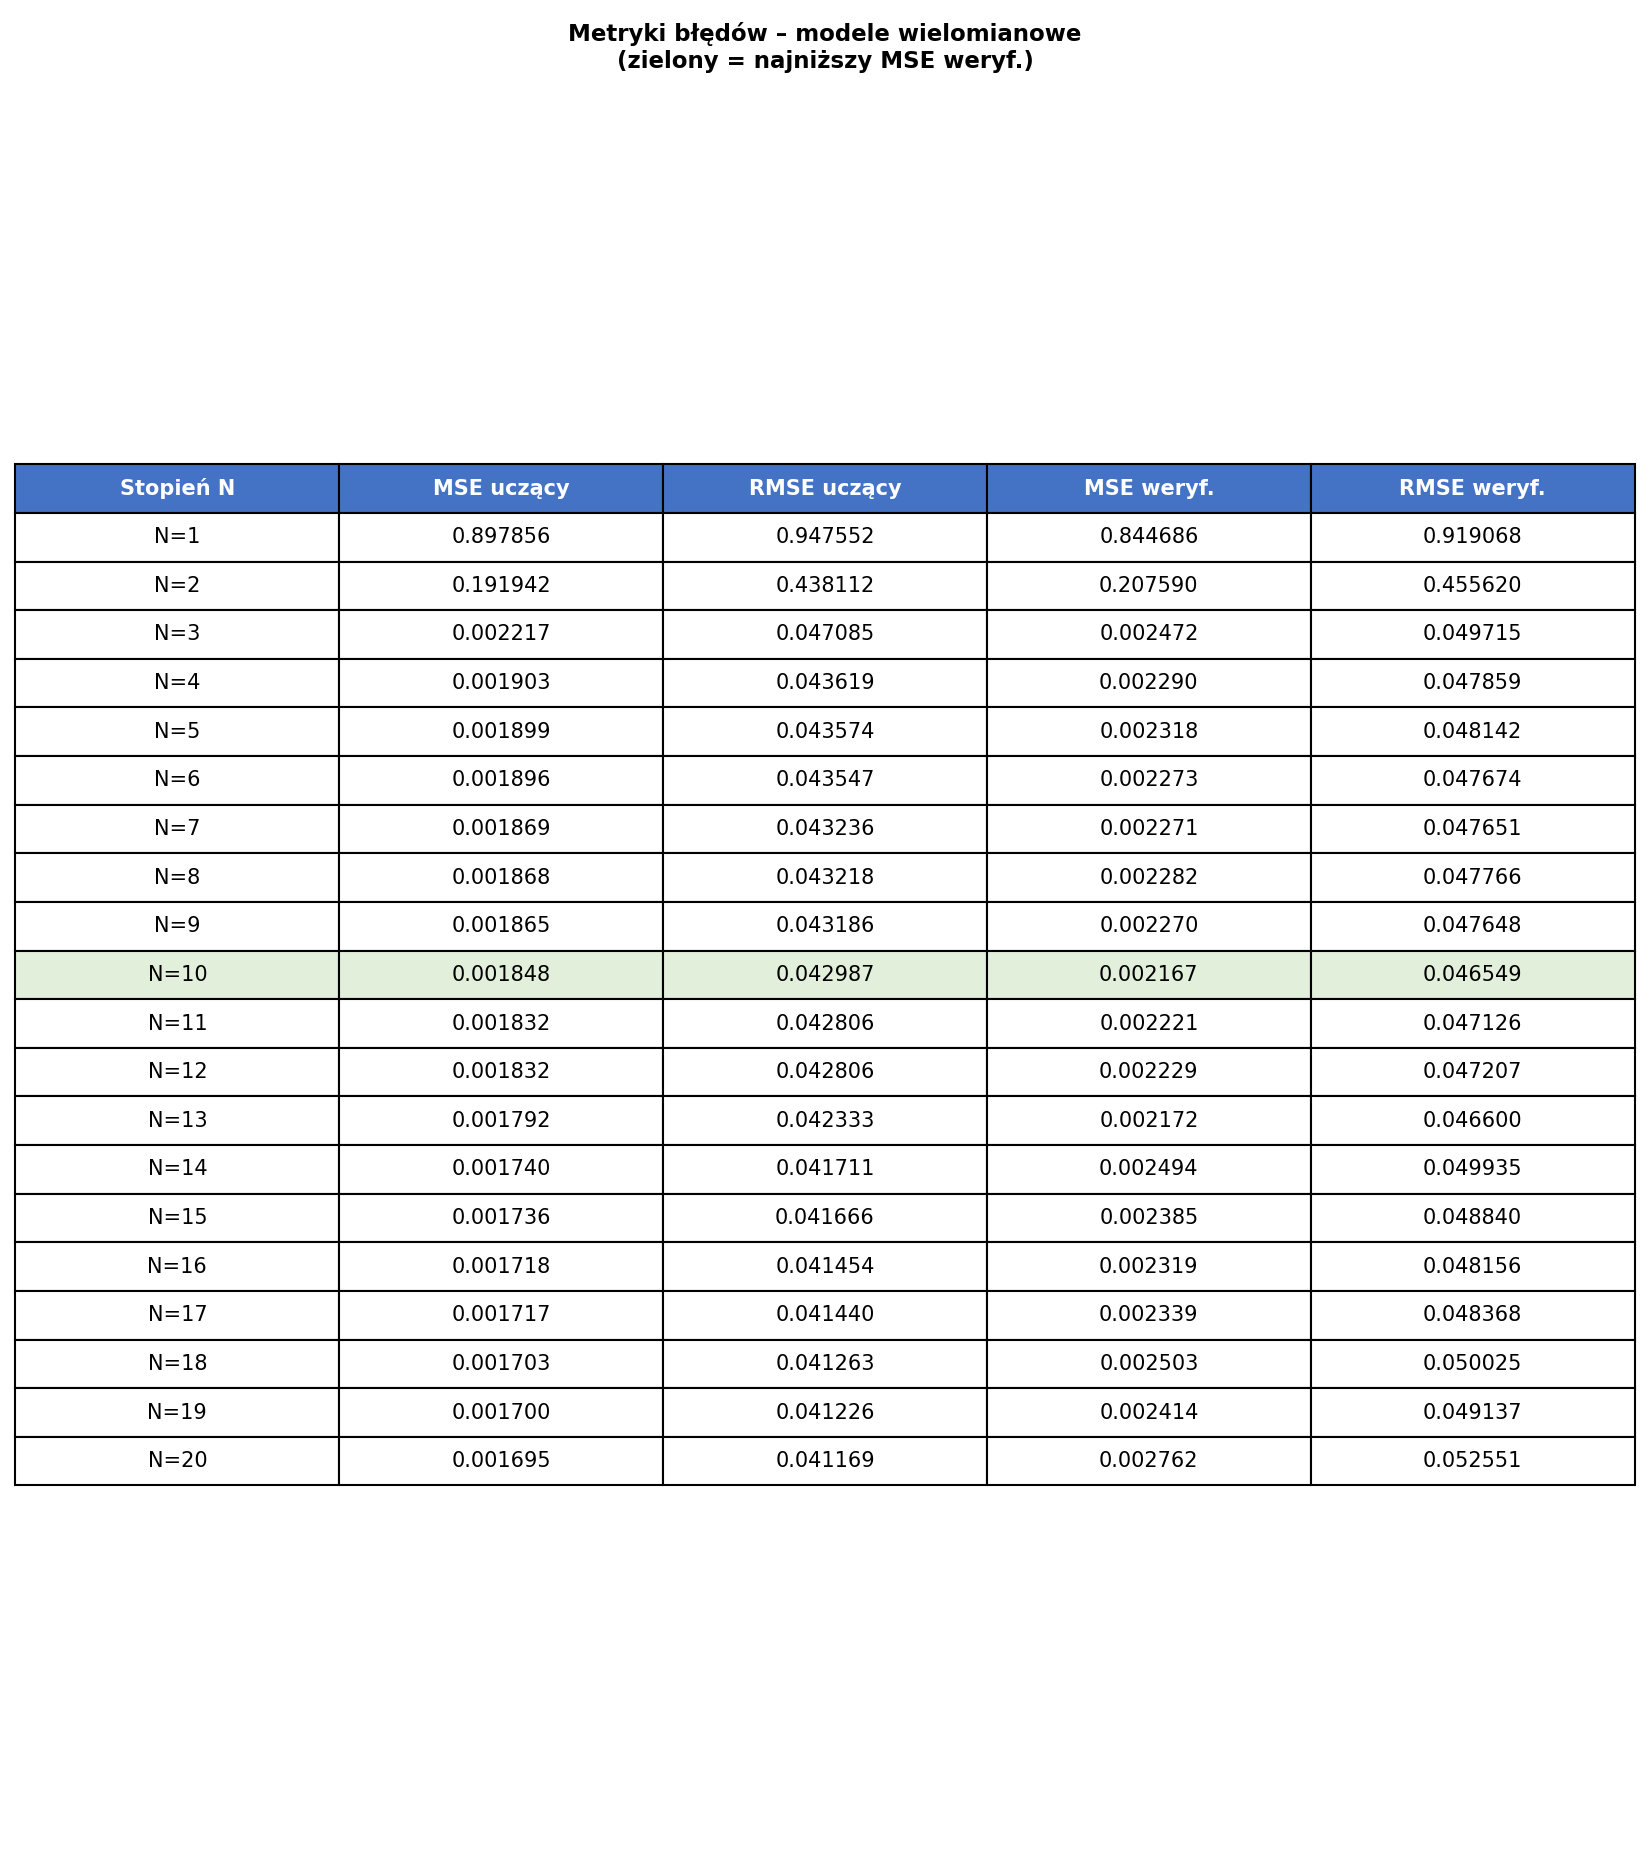

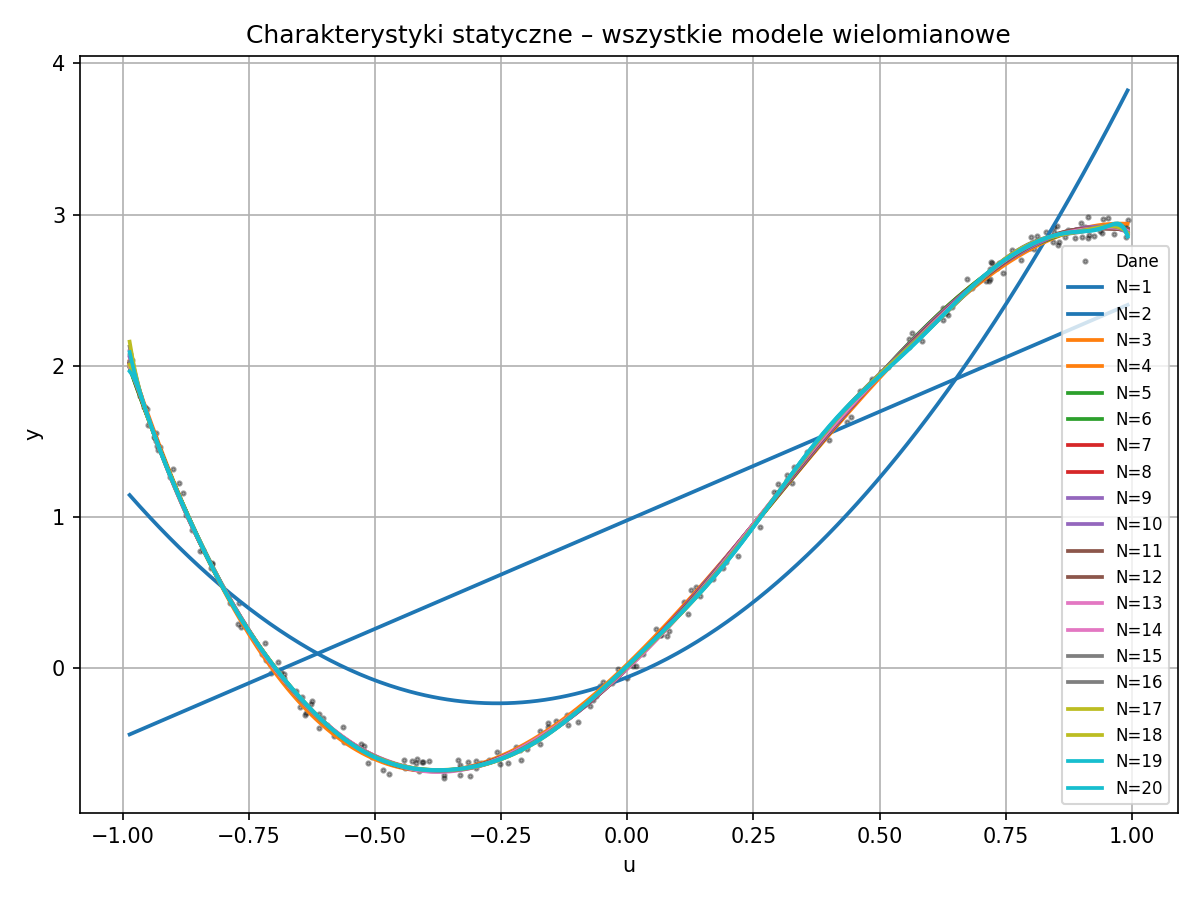

### Wykresy najlepszego modelu statycznego: N=10

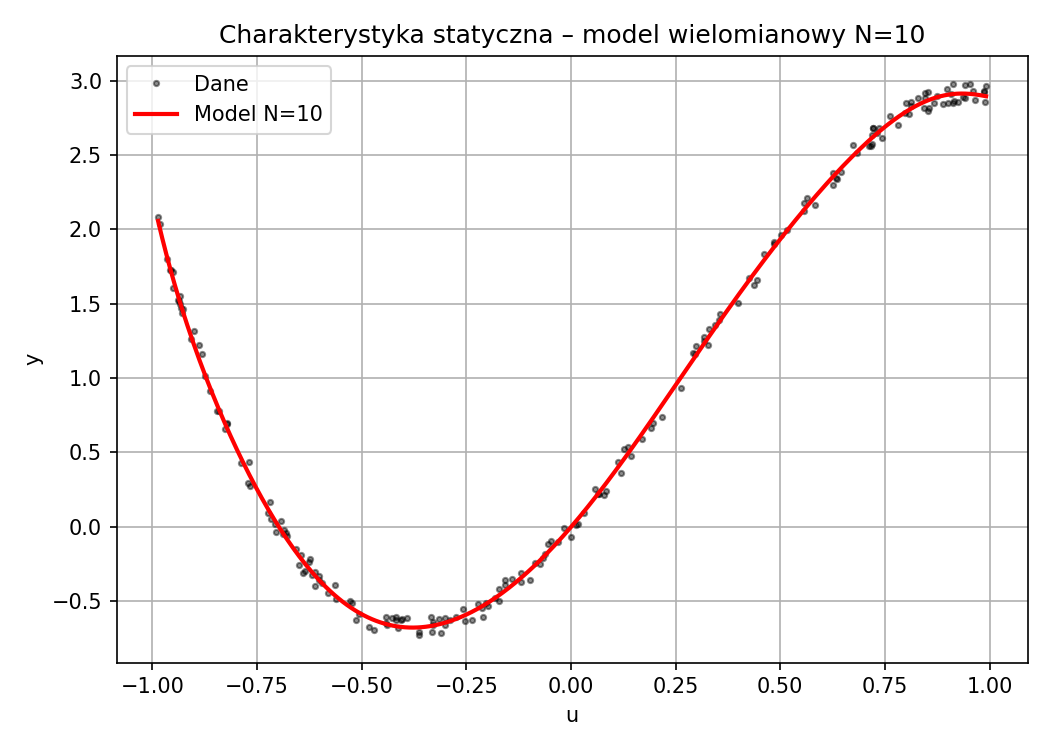

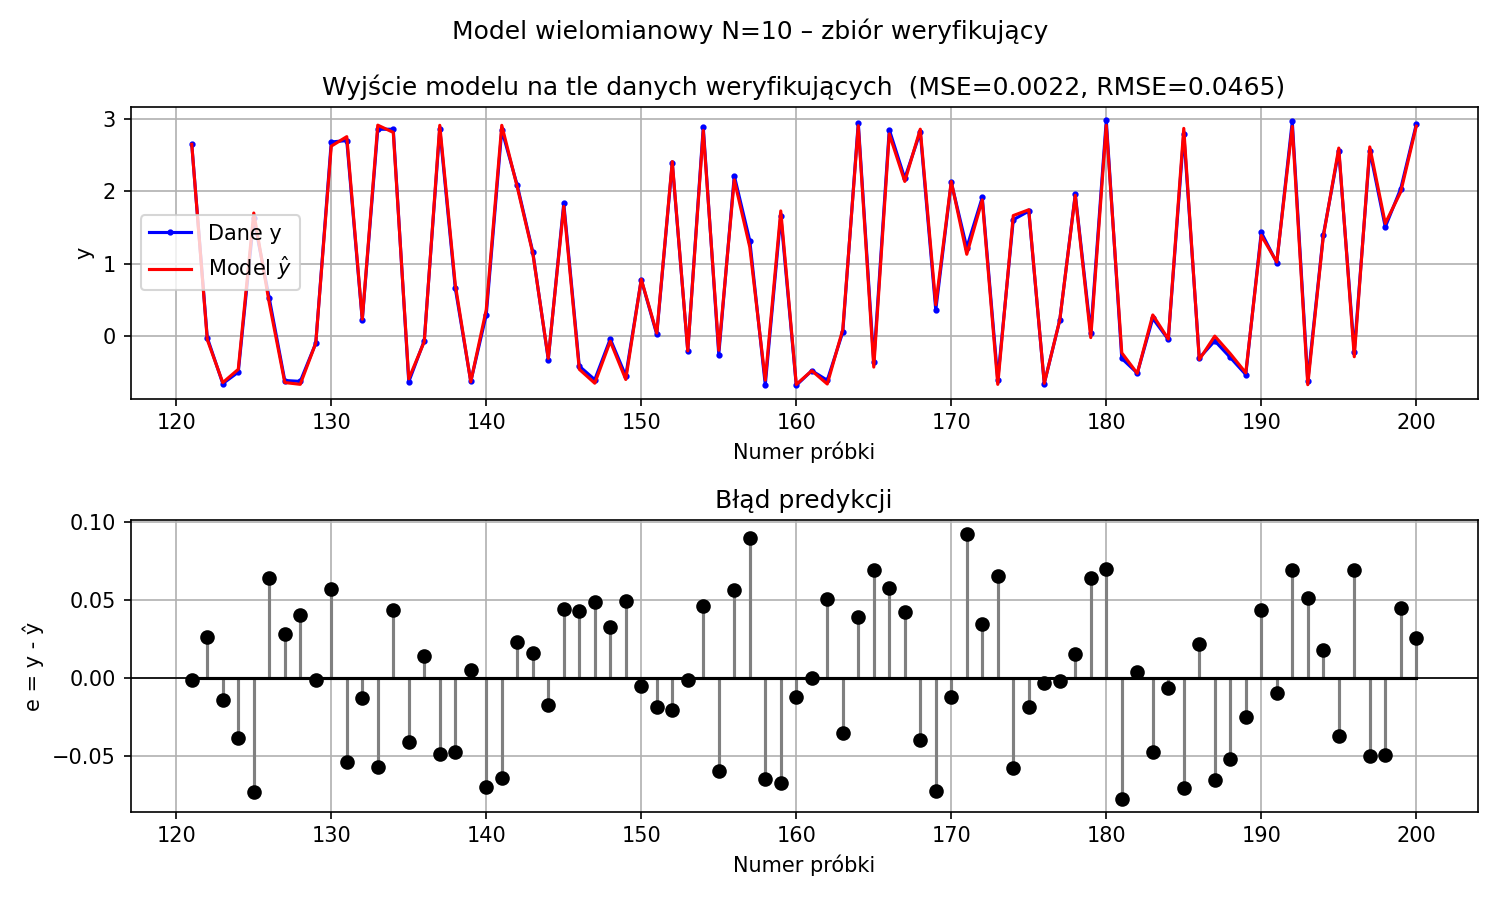

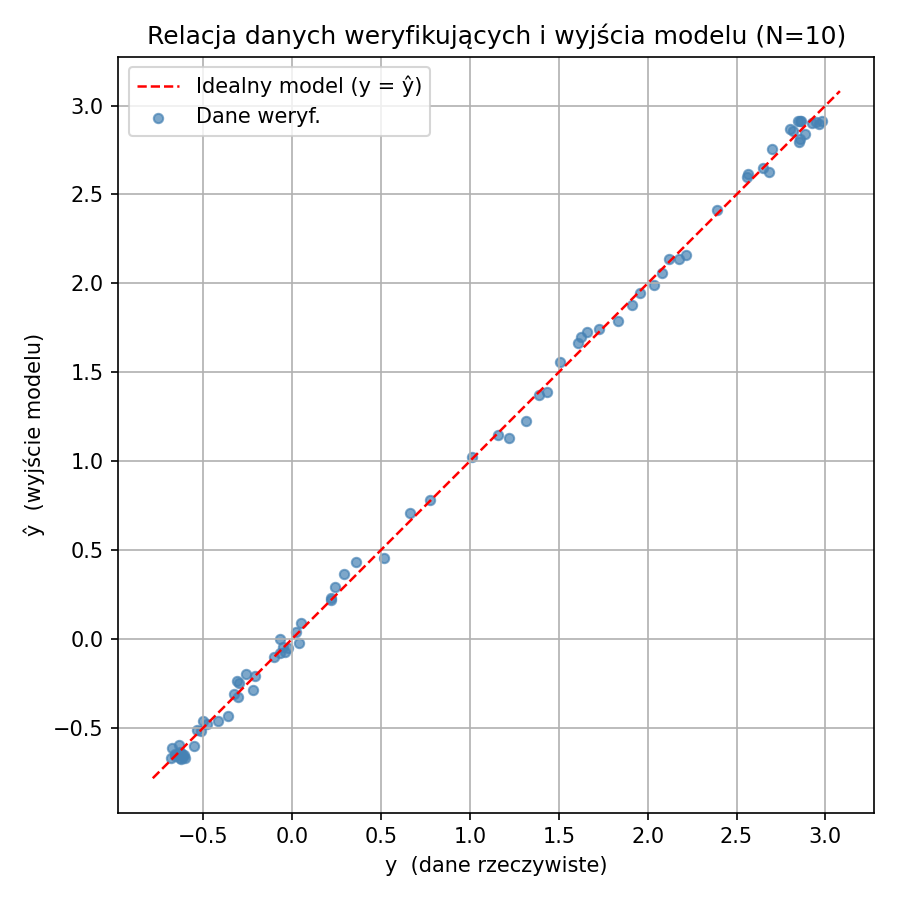

In [9]:
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_wielomianowy/tabela_metryk_wielomianowe.png", width=900)
display_png("indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_wielomianowy/poly_wszystkie_charakterystyki.png", width=760)

best_degree = int(best_poly["degree"])
display(Markdown(f"### Wykresy najlepszego modelu statycznego: N={best_degree}"))
display_png(f"indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_wielomianowy/poly{best_degree}/poly{best_degree}_charakterystyka.png", width=700)
display_png(f"indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_wielomianowy/poly{best_degree}/poly{best_degree}_weryfikacja_przebieg.png")
display_png(f"indetyfikacja_modeli_statycznych/obrazki_charakterystyki_statycznej/model_wielomianowy/poly{best_degree}/poly{best_degree}_weryfikacja_scatter.png", width=620)

**Wybór modelu statycznego:** za najlepszy przyjęto model o najmniejszym MSE na zbiorze weryfikującym. Porównanie błędów uczących i weryfikujących pozwala sprawdzić, czy wzrost stopnia wielomianu poprawia uogólnianie, czy tylko dopasowanie do danych uczących.

# 2. Identyfikacja modeli dynamicznych

Dane dynamiczne są dostarczone w dwóch plikach: zbiór uczący i zbiór weryfikujący. Modele dynamiczne porównano w trybie bez rekurencji oraz z rekurencją. Do wyboru końcowego istotny jest przede wszystkim tryb rekurencyjny, bo odpowiada pracy modelu jako symulatora.

In [10]:
dynamic_import = load_module("modi_dynamic_import", DYNAMIC_CODE / "import_danych.py")
dynamic_models = load_module("modi_dynamic_models", DYNAMIC_CODE / "modele_dynamiczne.py")
dynamic_plotting = load_module("modi_dynamic_plotting", DYNAMIC_CODE / "rysowanie.py")

ARX_ORDERS = [1, 2, 3]

# Etap 1: szerokie przeszukiwanie, odpowiadające ustawieniu pretrained = False.
pretrained = False
if pretrained == False:
    NARX_PRETRAIN_ORDERS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]
    NARX_PRETRAIN_DEGREES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]

# Etap 2: przeszukiwanie zawężone, odpowiadające ustawieniu pretrained = True.
pretrained = True
if pretrained == True:
    NARX_ORDERS = [13, 14, 15, 16, 17, 18, 19, 20]
    NARX_DEGREES = [3, 4, 5, 6]

dane_dyn = dynamic_import.ImportDynamicData(base_dir=str(ROOT))
plotter_dyn = dynamic_plotting.PlotDynamic(dane_dyn.out_dir)

if GENERATE_NOTEBOOK_FIGURES:
    plotter_dyn.plot_training_data(dane_dyn.u_ucz, dane_dyn.y_ucz)
    plotter_dyn.plot_verification_data(dane_dyn.u_wer, dane_dyn.y_wer)
    plt.close("all")

print(f"Zbiór uczący: {dane_dyn.N_ucz} próbek")
print(f"Zbiór weryfikujący: {dane_dyn.N_wer} próbek")

Zbiór uczący: 2000 próbek
Zbiór weryfikujący: 2000 próbek


## 2a. Dane dynamiczne

Poniżej znajdują się przebiegi sygnałów wejściowych i wyjściowych dla zbioru uczącego oraz weryfikującego.

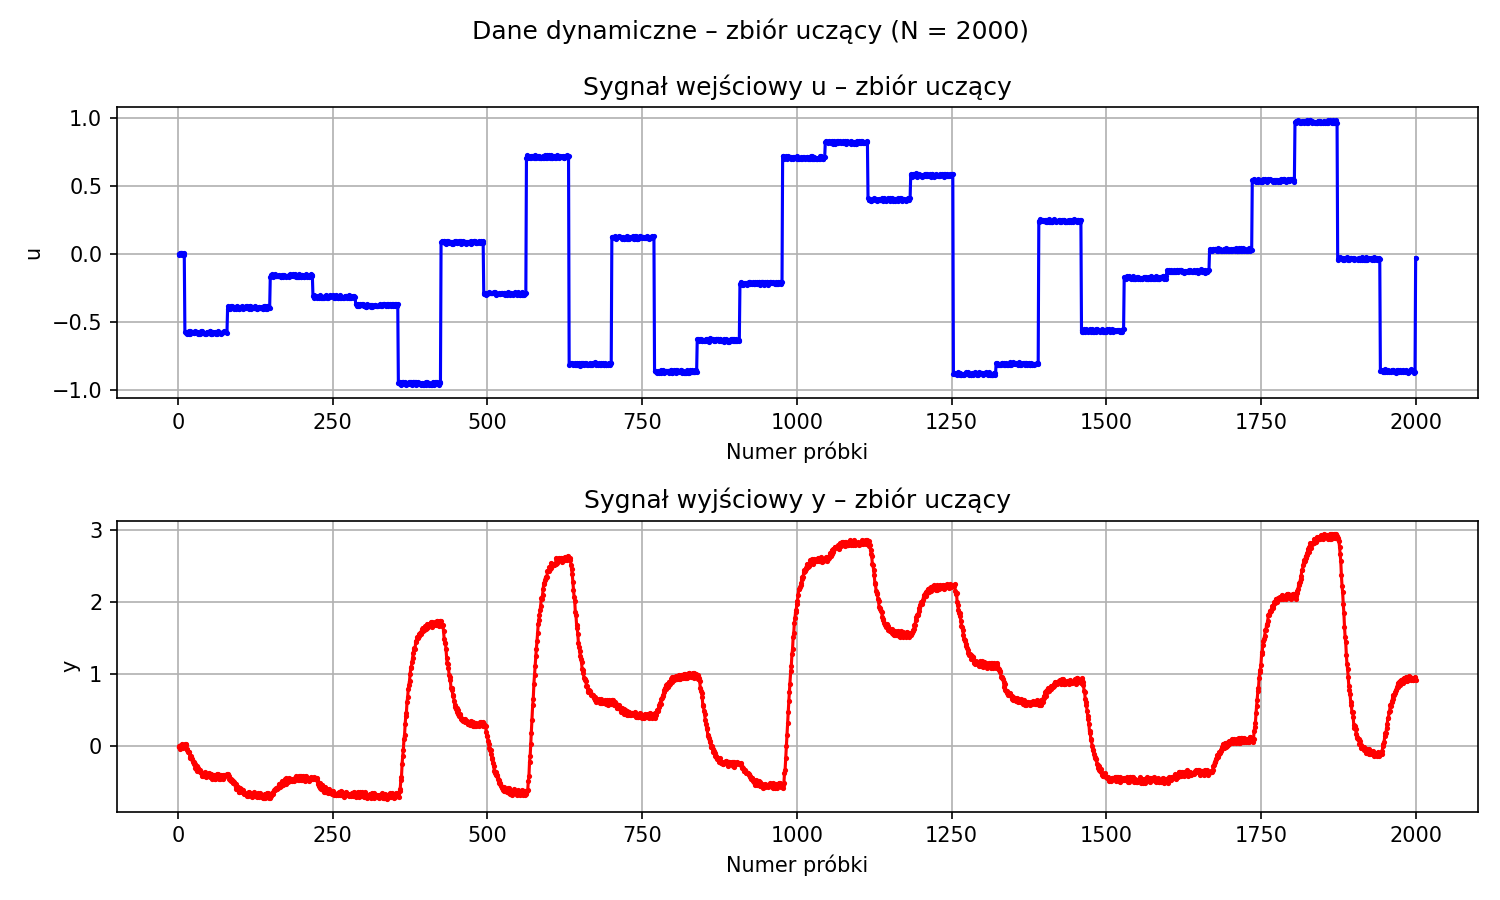

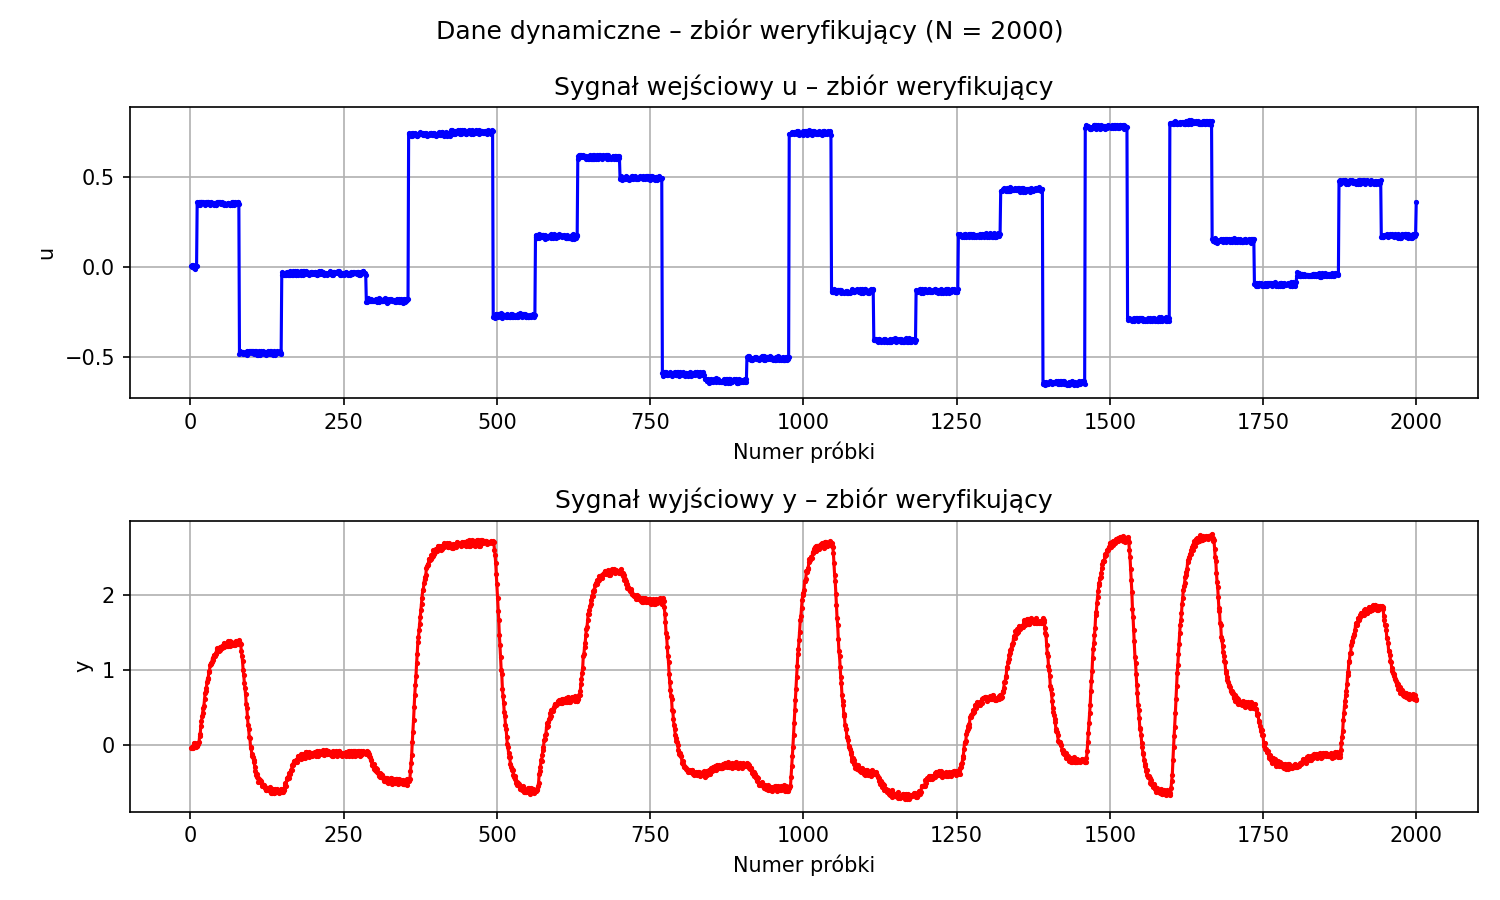

In [11]:
display_png("identyfikacja_modeli_dynamicznych/obrazki/dane_surowe/dane_dynamiczne_uczace.png")
display_png("identyfikacja_modeli_dynamicznych/obrazki/dane_surowe/dane_dynamiczne_weryfikujace.png")

## 2b. Dynamiczne modele liniowe ARX

Dla rzędów $n_A=n_B\in\{1,2,3\}$ wyznaczono modele:

$$y(k)=\sum_{i=1}^{n_B}b_i u(k-i)+\sum_{i=1}^{n_A}a_i y(k-i).$$

Tryb bez rekurencji używa zmierzonych opóźnionych wartości $y$, natomiast tryb rekurencyjny używa wcześniejszych wartości wyjścia modelu $\hat{y}$.

In [12]:
def evaluate_arx(order: int) -> dict:
    model = dynamic_models.ARXModel(nA=order, nB=order).fit(dane_dyn.u_ucz, dane_dyn.y_ucz)
    row = {"order": order, "params": 2 * order, "model": model}
    for recursive, tag in [(False, "nr"), (True, "r")]:
        y_hat_ucz, n = model.predict(dane_dyn.u_ucz, dane_dyn.y_ucz, recursive=recursive)
        m_ucz = model.evaluate(dane_dyn.y_ucz[n:], y_hat_ucz)
        y_hat_wer, n = model.predict(dane_dyn.u_wer, dane_dyn.y_wer, recursive=recursive)
        m_wer = model.evaluate(dane_dyn.y_wer[n:], y_hat_wer)
        if GENERATE_NOTEBOOK_FIGURES:
            plotter_dyn.plot_verification_results(
                dane_dyn.y_wer[n:], y_hat_wer, n,
                m_wer["mse"], m_wer["rmse"], order, recursive,
            )
            plotter_dyn.plot_scatter(dane_dyn.y_wer[n:], y_hat_wer, order, recursive)
        row[f"mse_ucz_{tag}"] = m_ucz["mse"]
        row[f"rmse_ucz_{tag}"] = m_ucz["rmse"]
        row[f"mse_wer_{tag}"] = m_wer["mse"]
        row[f"rmse_wer_{tag}"] = m_wer["rmse"]
    return row

arx_results = [evaluate_arx(order) for order in ARX_ORDERS]
if GENERATE_NOTEBOOK_FIGURES:
    plotter_dyn.plot_metrics_table(arx_results)
    plt.close("all")

best_arx_index = min(range(len(arx_results)), key=lambda i: arx_results[i]["mse_wer_r"])
best_arx = arx_results[best_arx_index]

show_table(arx_results, [
    ("order", "n"), ("params", "L. par."),
    ("mse_ucz_nr", "MSE ucz. NR"), ("rmse_ucz_nr", "RMSE ucz. NR"),
    ("mse_wer_nr", "MSE wer. NR"), ("rmse_wer_nr", "RMSE wer. NR"),
    ("mse_ucz_r", "MSE ucz. R"), ("rmse_ucz_r", "RMSE ucz. R"),
    ("mse_wer_r", "MSE wer. R"), ("rmse_wer_r", "RMSE wer. R"),
], "Metryki modeli ARX", highlight_index=best_arx_index)

display(Markdown(
    f"Najlepszy model liniowy w trybie rekurencyjnym: **ARX rzędu {best_arx['order']}** "
    f"(MSE={best_arx['mse_wer_r']:.6f}, RMSE={best_arx['rmse_wer_r']:.6f})."
))

n,L. par.,MSE ucz. NR,RMSE ucz. NR,MSE wer. NR,RMSE wer. NR,MSE ucz. R,RMSE ucz. R,MSE wer. R,RMSE wer. R
1,2,0.001974,0.044427,0.002631,0.051291,2.821949,1.679866,1.202792,1.096719
2,4,0.001923,0.043857,0.002384,0.048823,2.625758,1.620419,1.213854,1.101751
3,6,0.001594,0.039920,0.001798,0.042403,2.098656,1.448674,1.219444,1.104284


Najlepszy model liniowy w trybie rekurencyjnym: **ARX rzędu 1** (MSE=1.202792, RMSE=1.096719).

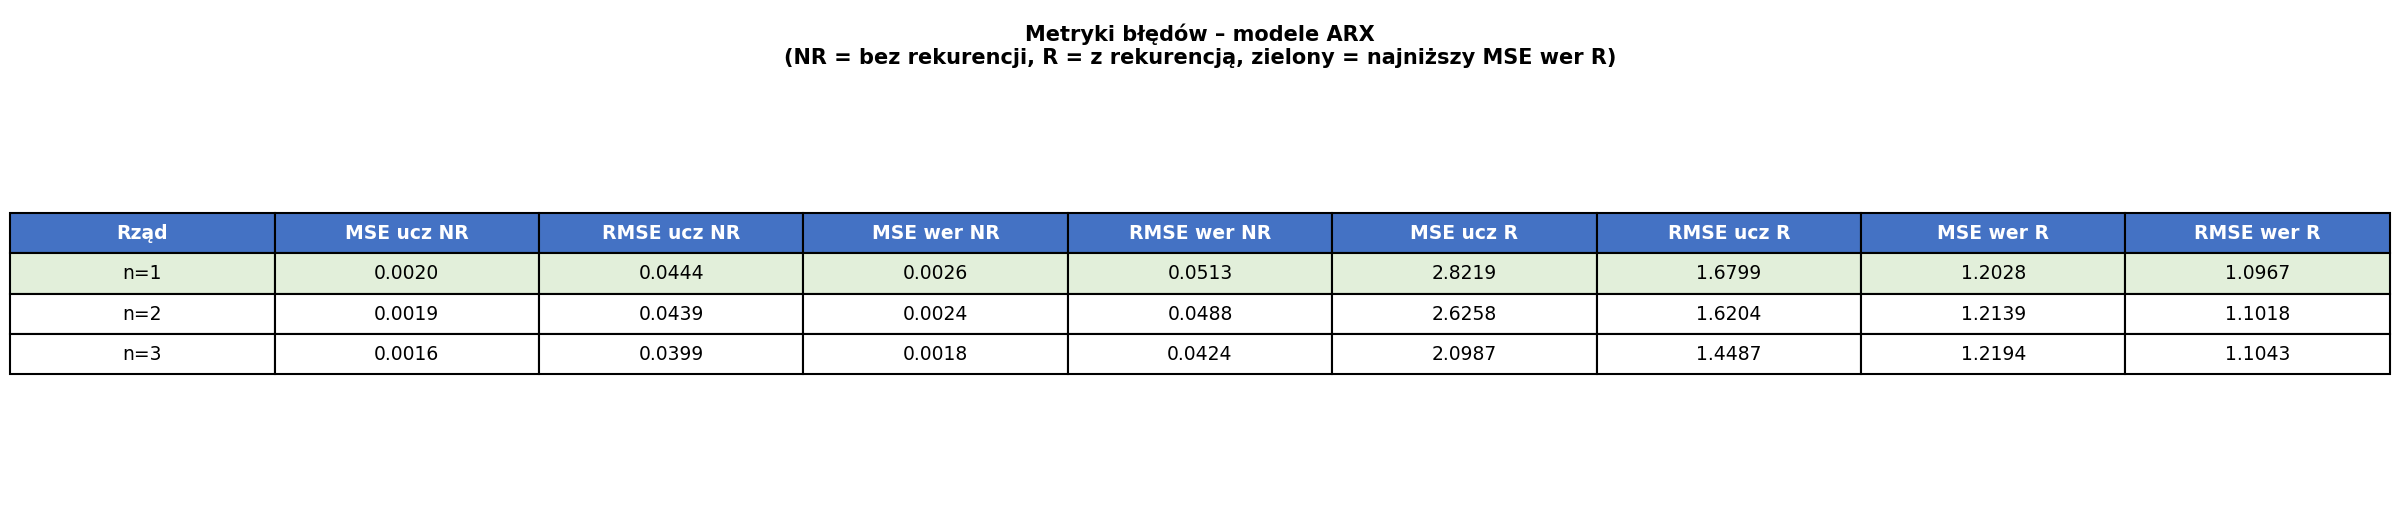

### Wykresy najlepszego modelu ARX w trybie rekurencyjnym: n=1

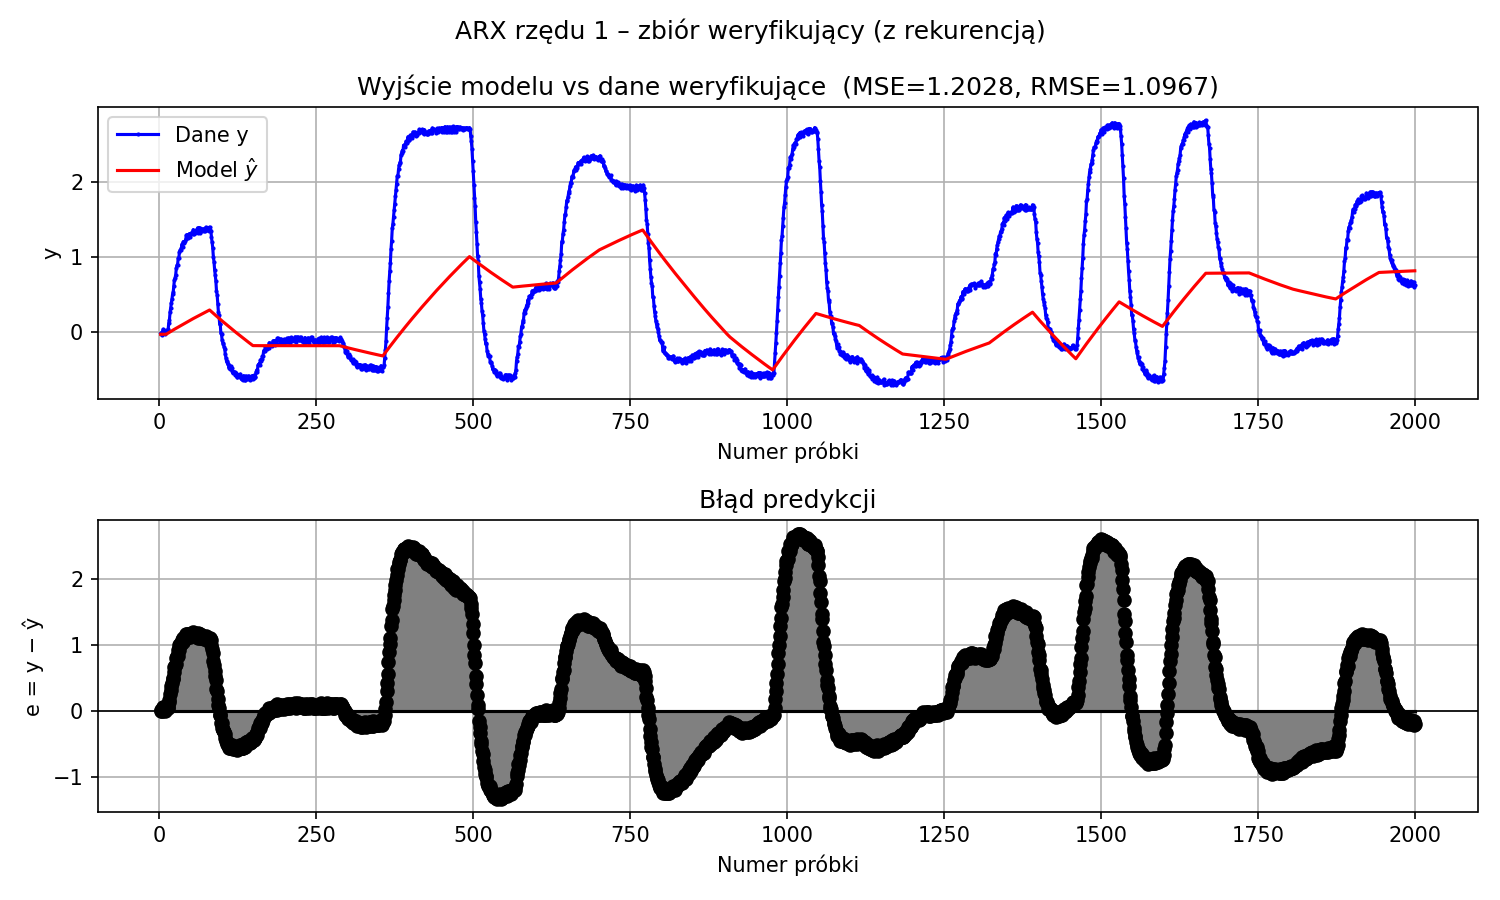

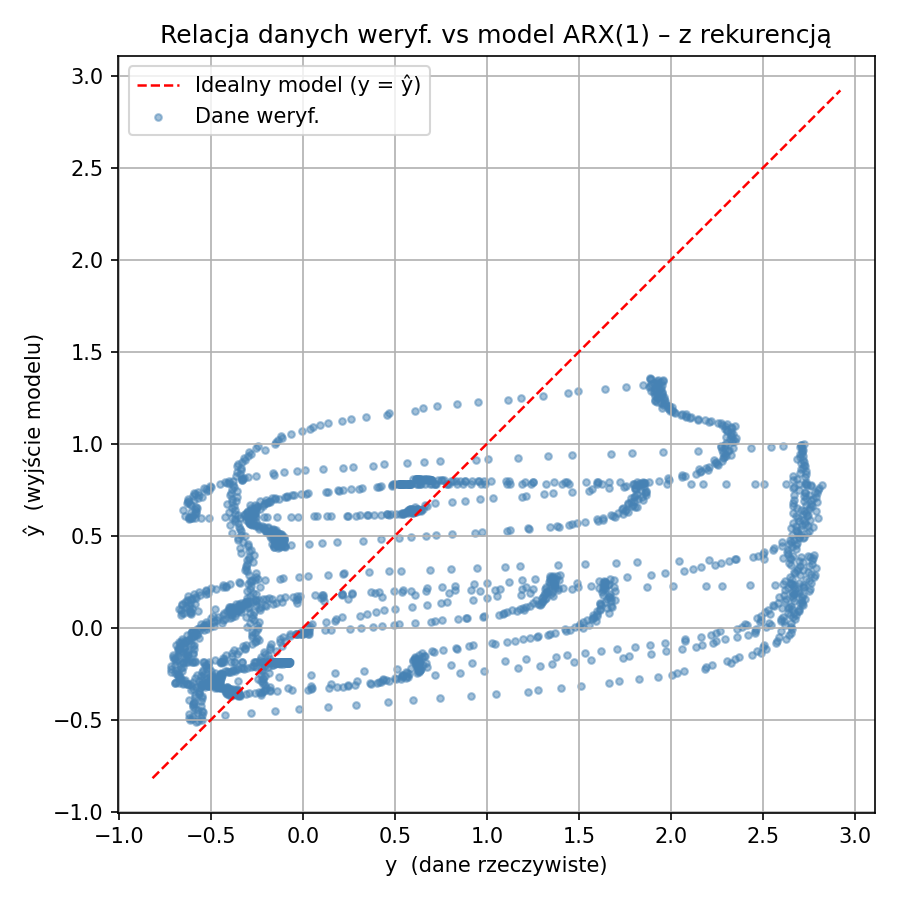

In [13]:
display_png("identyfikacja_modeli_dynamicznych/obrazki/modele_arx/tabela_metryk_arx.png", width=1100)

best_arx_order = int(best_arx["order"])
display(Markdown(f"### Wykresy najlepszego modelu ARX w trybie rekurencyjnym: n={best_arx_order}"))
display_png(f"identyfikacja_modeli_dynamicznych/obrazki/modele_arx/order{best_arx_order}/order{best_arx_order}_r_weryfikacja.png")
display_png(f"identyfikacja_modeli_dynamicznych/obrazki/modele_arx/order{best_arx_order}/order{best_arx_order}_r_scatter.png", width=620)

**Komentarz:** tryb bez rekurencji daje mniejsze błędy, ponieważ korzysta z rzeczywistych opóźnionych wyjść i model w takiej formie działa. Natomiast gdy spróbuje się go użyć praktycznie czyli w trybie rekurencyjnym błędy zaczynają się akumulować, ten tryb ujawnia rzeczywistą przydatność modelu do symulacji procesu i jest ona wątpliwa.

## 2c. Dynamiczne modele nieliniowe NARX

Rozważono wielomianowe modele dynamiczne bez wyrazów mieszanych:

$$y(k)=\sum_{i=1}^{n_B}\sum_{p=1}^{d} w_{i,p}u(k-i)^p + \sum_{i=1}^{n_A}\sum_{p=1}^{d} v_{i,p}y(k-i)^p.$$

W tym notebooku zakres przeszukiwania określają listy `NARX_ORDERS` i `NARX_DEGREES`. Liczba parametrów wynosi $2n_A d$ przy $n_A=n_B$.

Przeszukiwanie przeprowadzono **dwuetapowo**:
1. **Etap 1 (`pretrained = False`)** – szerokie przeszukiwanie siatki $n_A \in \{1\text{–}10, 20, 30, 40, 50\}$, $d \in \{1\text{–}10, 20, 30, 40, 50\}$ w celu ustalenia obiecującego obszaru.
2. **Etap 2 (`pretrained = True`)** – zawężone przeszukiwanie wokół minimum znalezionego w etapie 1.

### Etap 1 – wstępne przeszukiwanie (`pretrained = False`)

In [14]:
RUN_NARX_PRETRAIN = False   # True = przelicz na nowo (wolne, ~196 modeli); False = pokaż archiwalne wyniki

if RUN_NARX_PRETRAIN:
    pretrain_results = []
    for nA in NARX_PRETRAIN_ORDERS:
        for degree in NARX_PRETRAIN_DEGREES:
            n_params = 2 * nA * degree
            available = dane_dyn.N_ucz - nA
            if n_params > available:
                continue
            model = dynamic_models.NARXModel(nA=nA, nB=nA, deg=degree).fit(dane_dyn.u_ucz, dane_dyn.y_ucz)
            row = {"nA": nA, "deg": degree, "params": n_params}
            for recursive, tag in [(False, "nr"), (True, "r")]:
                y_hat_ucz, n = model.predict(dane_dyn.u_ucz, dane_dyn.y_ucz, recursive=recursive)
                m_ucz = model.evaluate(dane_dyn.y_ucz[n:], y_hat_ucz)
                y_hat_wer, n = model.predict(dane_dyn.u_wer, dane_dyn.y_wer, recursive=recursive)
                m_wer = model.evaluate(dane_dyn.y_wer[n:], y_hat_wer)
                row[f"mse_ucz_{tag}"] = m_ucz["mse"]
                row[f"rmse_ucz_{tag}"] = m_ucz["rmse"]
                row[f"mse_wer_{tag}"] = m_wer["mse"]
                row[f"rmse_wer_{tag}"] = m_wer["rmse"]
            pretrain_results.append(row)

    finite_pretrain = [r for r in pretrain_results if np.isfinite(r["mse_wer_r"])]
    best_pretrain = min(finite_pretrain, key=lambda r: r["mse_wer_r"])
    best_pretrain_index = pretrain_results.index(best_pretrain)

    show_table(pretrain_results, [
        ("nA", "nA=nB"), ("deg", "d"), ("params", "L. par."),
        ("mse_ucz_nr", "MSE ucz. NR"), ("mse_wer_nr", "MSE wer. NR"),
        ("mse_ucz_r",  "MSE ucz. R"),  ("mse_wer_r",  "MSE wer. R"),
    ], "Etap 1 – metryki modeli NARX (szerokie przeszukiwanie)", highlight_index=best_pretrain_index)

    display(Markdown(
        f"**Najlepszy model (etap 1):** NARX(nA=nB={best_pretrain['nA']}, d={best_pretrain['deg']}) "
        f"— MSE wer. R = {best_pretrain['mse_wer_r']:.6f}. "
        f"Na tej podstawie zawężono zakres do "
        f"`NARX_ORDERS = {NARX_ORDERS}`, `NARX_DEGREES = {NARX_DEGREES}`."
    ))
else:
    display(Markdown(
        "Szerokie przeszukiwanie przeprowadzono jednorazowo "
        f"na siatce `NARX_PRETRAIN_ORDERS = {NARX_PRETRAIN_ORDERS}` × "
        f"`NARX_PRETRAIN_DEGREES = {NARX_PRETRAIN_DEGREES}`.  \n"
        "**Najlepszy wynik (etap 1):** NARX(nA=nB=20, d=4) → MSE wer. R = 0.000573.  \n"
        f"Na tej podstawie zawężono zakres do "
        f"`NARX_ORDERS = {NARX_ORDERS}`, `NARX_DEGREES = {NARX_DEGREES}`."
    ))


Szerokie przeszukiwanie przeprowadzono jednorazowo na siatce `NARX_PRETRAIN_ORDERS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]` × `NARX_PRETRAIN_DEGREES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]`.  
**Najlepszy wynik (etap 1):** NARX(nA=nB=20, d=4) → MSE wer. R = 0.000573.  
Na tej podstawie zawężono zakres do `NARX_ORDERS = [13, 14, 15, 16, 17, 18, 19, 20]`, `NARX_DEGREES = [3, 4, 5, 6]`.

### Etap 2 – zawężone przeszukiwanie (`pretrained = True`)

Na podstawie wyników etapu 1 zawężono siatkę do $n_A \in \{13\text{–}20\}$, $d \in \{3, 4, 5, 6\}$ i powtórzono przeszukiwanie.

In [15]:
def evaluate_narx(nA: int, degree: int) -> dict | None:
    n_params = 2 * nA * degree
    available = dane_dyn.N_ucz - nA
    if n_params > available:
        return None
    model = dynamic_models.NARXModel(nA=nA, nB=nA, deg=degree).fit(dane_dyn.u_ucz, dane_dyn.y_ucz)
    row = {"nA": nA, "deg": degree, "params": n_params, "model": model}
    for recursive, tag in [(False, "nr"), (True, "r")]:
        y_hat_ucz, n = model.predict(dane_dyn.u_ucz, dane_dyn.y_ucz, recursive=recursive)
        m_ucz = model.evaluate(dane_dyn.y_ucz[n:], y_hat_ucz)
        y_hat_wer, n = model.predict(dane_dyn.u_wer, dane_dyn.y_wer, recursive=recursive)
        m_wer = model.evaluate(dane_dyn.y_wer[n:], y_hat_wer)
        if GENERATE_NOTEBOOK_FIGURES and np.isfinite(m_wer["mse"]):
            plotter_dyn.plot_narx_verification_results(
                dane_dyn.y_wer[n:], y_hat_wer, n,
                m_wer["mse"], m_wer["rmse"], nA, degree, recursive,
            )
            plotter_dyn.plot_narx_scatter(dane_dyn.y_wer[n:], y_hat_wer, nA, degree, recursive)
        row[f"mse_ucz_{tag}"] = m_ucz["mse"]
        row[f"rmse_ucz_{tag}"] = m_ucz["rmse"]
        row[f"mse_wer_{tag}"] = m_wer["mse"]
        row[f"rmse_wer_{tag}"] = m_wer["rmse"]
    return row

narx_results = []
for nA in NARX_ORDERS:
    for degree in NARX_DEGREES:
        result = evaluate_narx(nA, degree)
        if result is not None:
            narx_results.append(result)

if GENERATE_NOTEBOOK_FIGURES:
    plotter_dyn.plot_narx_metrics_table(narx_results)
    plt.close("all")

finite_narx = [r for r in narx_results if np.isfinite(r["mse_wer_r"])]
best_narx = min(finite_narx, key=lambda r: r["mse_wer_r"])
best_narx_index = narx_results.index(best_narx)

show_table(narx_results, [
    ("nA", "nA=nB"), ("deg", "d"), ("params", "L. par."),
    ("mse_ucz_nr", "MSE ucz. NR"), ("rmse_ucz_nr", "RMSE ucz. NR"),
    ("mse_wer_nr", "MSE wer. NR"), ("rmse_wer_nr", "RMSE wer. NR"),
    ("mse_ucz_r", "MSE ucz. R"), ("rmse_ucz_r", "RMSE ucz. R"),
    ("mse_wer_r", "MSE wer. R"), ("rmse_wer_r", "RMSE wer. R"),
], "Metryki modeli NARX", highlight_index=best_narx_index)

display(Markdown(
    f"Najlepszy model nieliniowy w trybie rekurencyjnym: **NARX(nA=nB={best_narx['nA']}, d={best_narx['deg']})** "
    f"z {best_narx['params']} parametrami "
    f"(MSE={best_narx['mse_wer_r']:.6f}, RMSE={best_narx['rmse_wer_r']:.6f})."
))

nA=nB,d,L. par.,MSE ucz. NR,RMSE ucz. NR,MSE wer. NR,RMSE wer. NR,MSE ucz. R,RMSE ucz. R,MSE wer. R,RMSE wer. R
13,3,78,0.000582,0.024120,0.000620,0.024905,0.000735,0.027106,0.000725,0.026924
13,4,104,0.000559,0.023643,0.000615,0.024802,0.000556,0.023570,0.000589,0.024268
13,5,130,0.000552,0.023496,0.000623,0.024957,0.000555,0.023555,0.000598,0.024449
13,6,156,0.000544,0.023324,0.000631,0.025118,0.000555,0.023550,0.000614,0.024783
14,3,84,0.000576,0.023996,0.000615,0.024804,0.000733,0.027069,0.000713,0.026693
14,4,112,0.000548,0.023412,0.000611,0.024728,0.000545,0.023353,0.000581,0.024107
14,5,140,0.000541,0.023266,0.000622,0.024933,0.000544,0.023327,0.000594,0.024362
14,6,168,0.000532,0.023060,0.000632,0.025137,0.000540,0.023246,0.000610,0.024699
15,3,90,0.000569,0.023862,0.000610,0.024689,0.000732,0.027055,0.000708,0.026611
15,4,120,0.000536,0.023142,0.000605,0.024598,0.000535,0.023124,0.000580,0.024078


Najlepszy model nieliniowy w trybie rekurencyjnym: **NARX(nA=nB=16, d=4)** z 128 parametrami (MSE=0.000570, RMSE=0.023884).

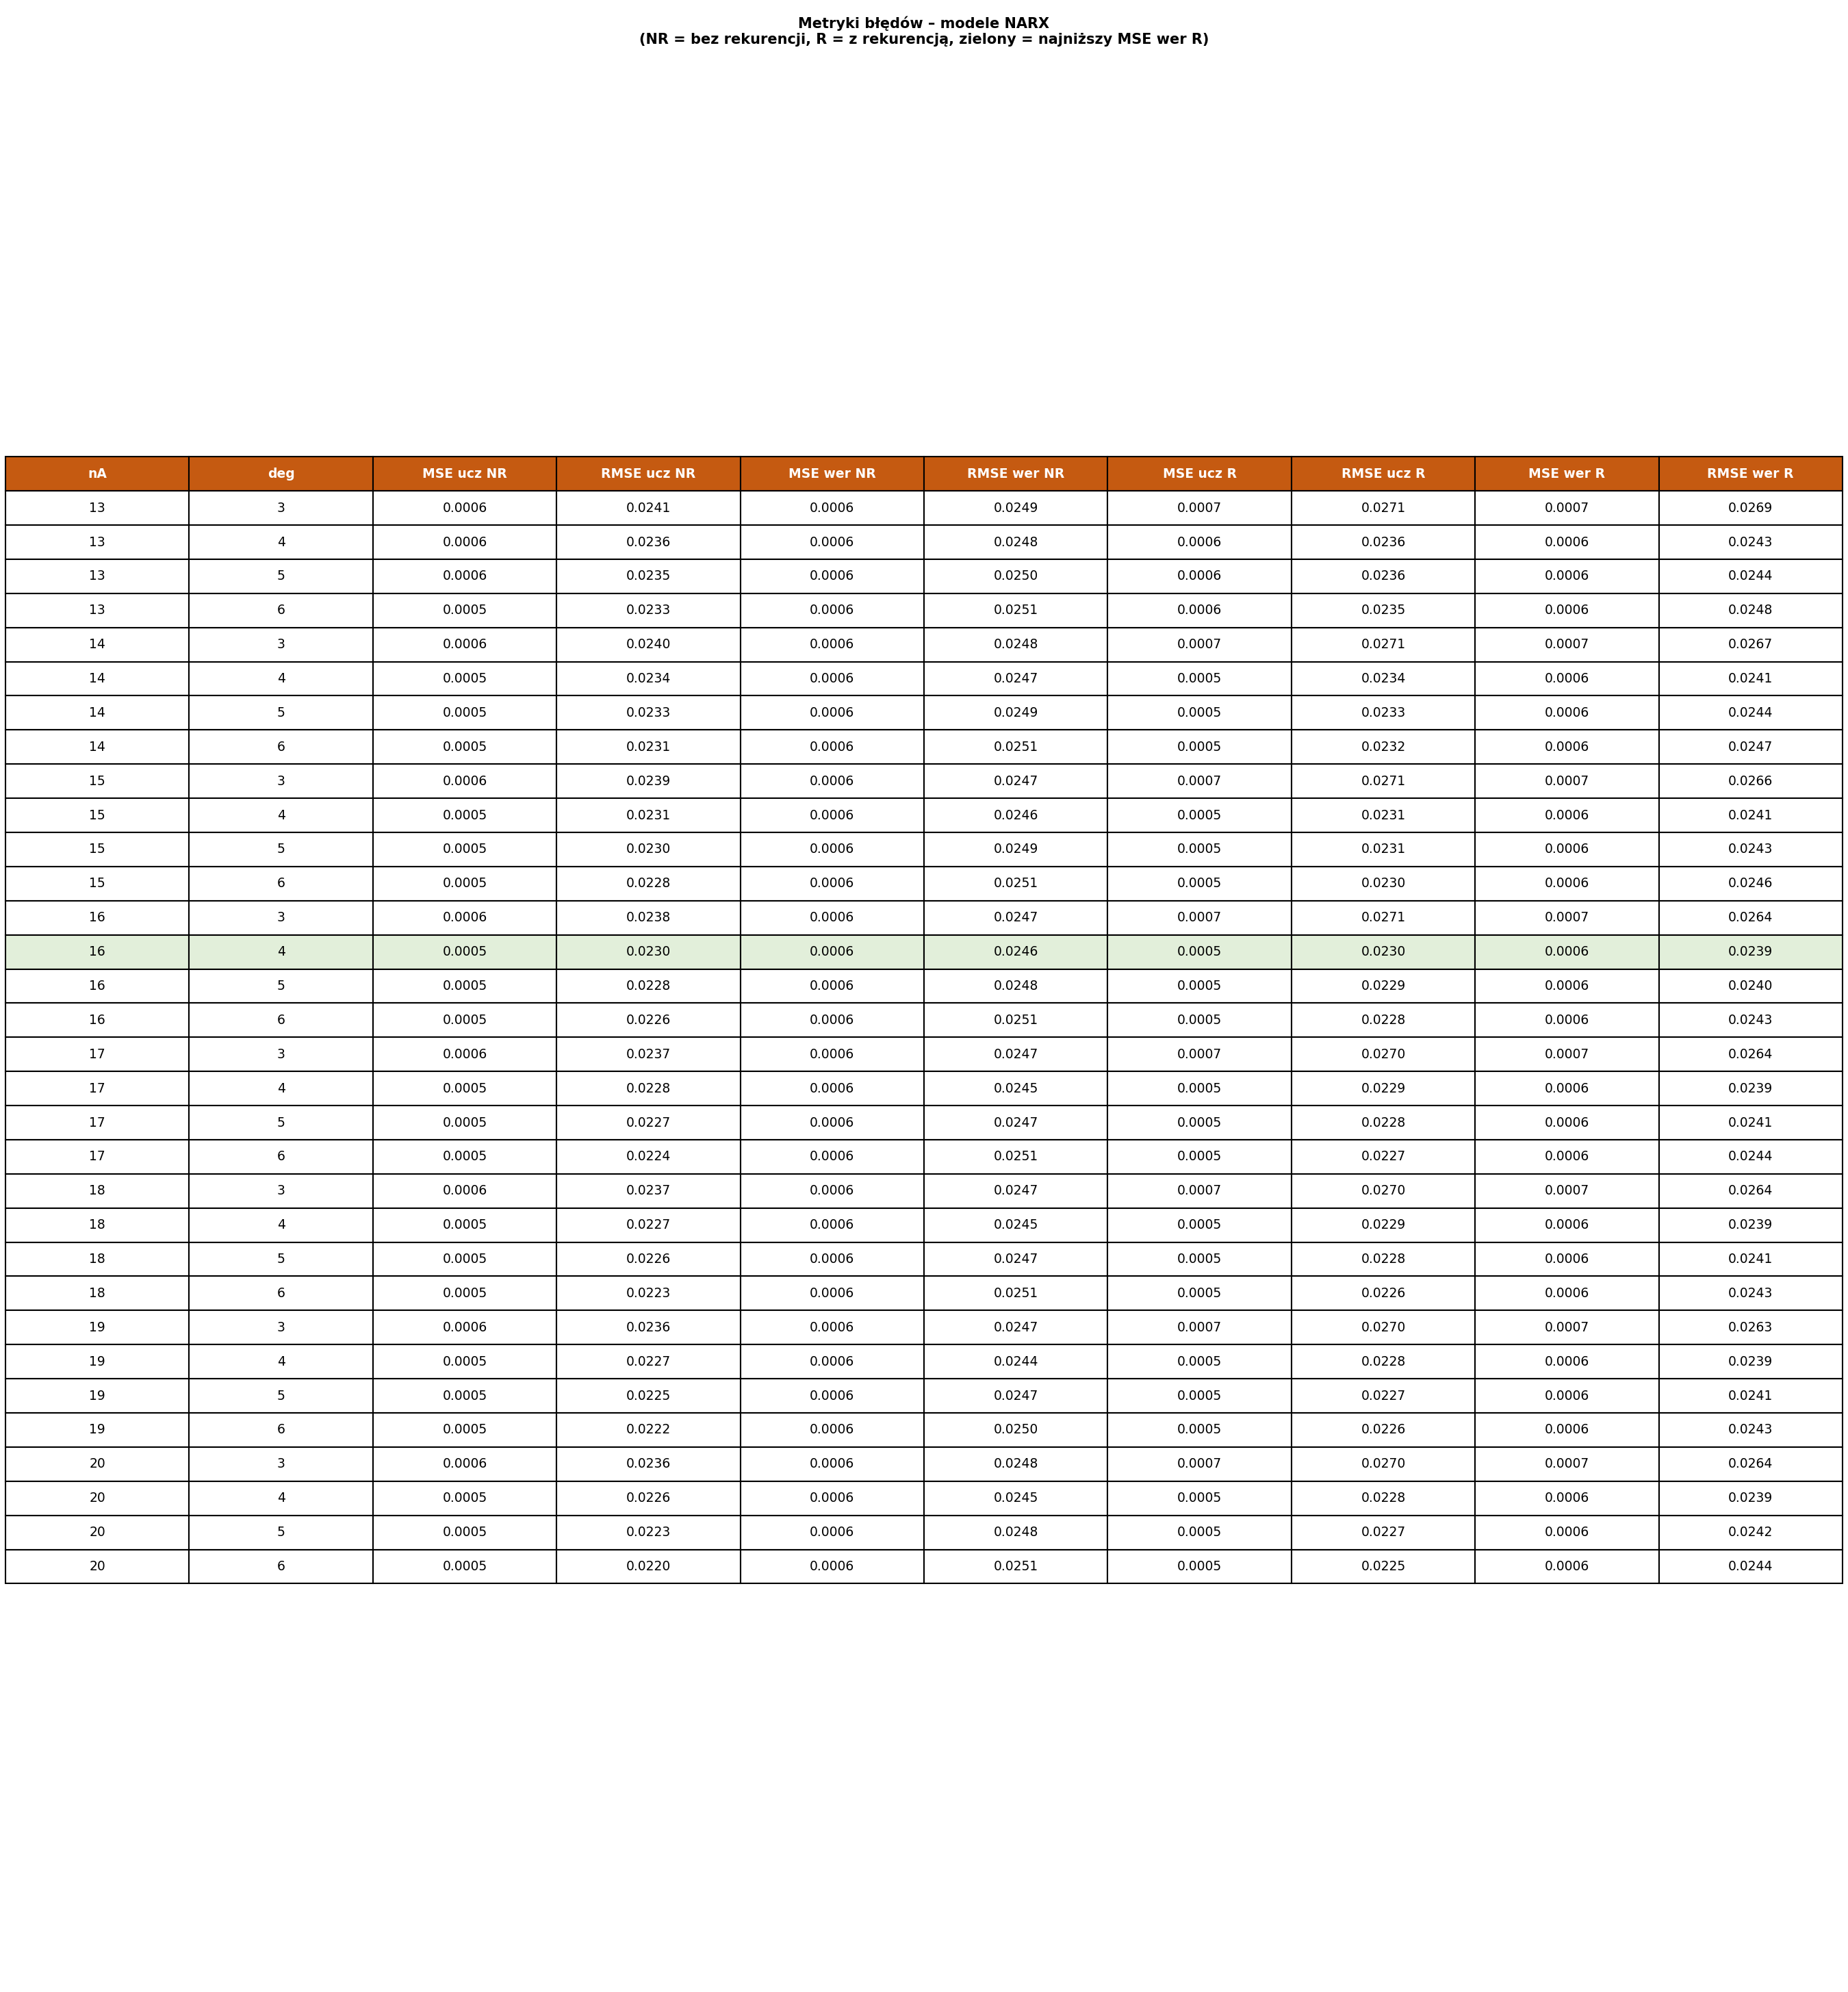

### Wykresy najlepszego modelu NARX w trybie rekurencyjnym: nA=nB=16, d=4

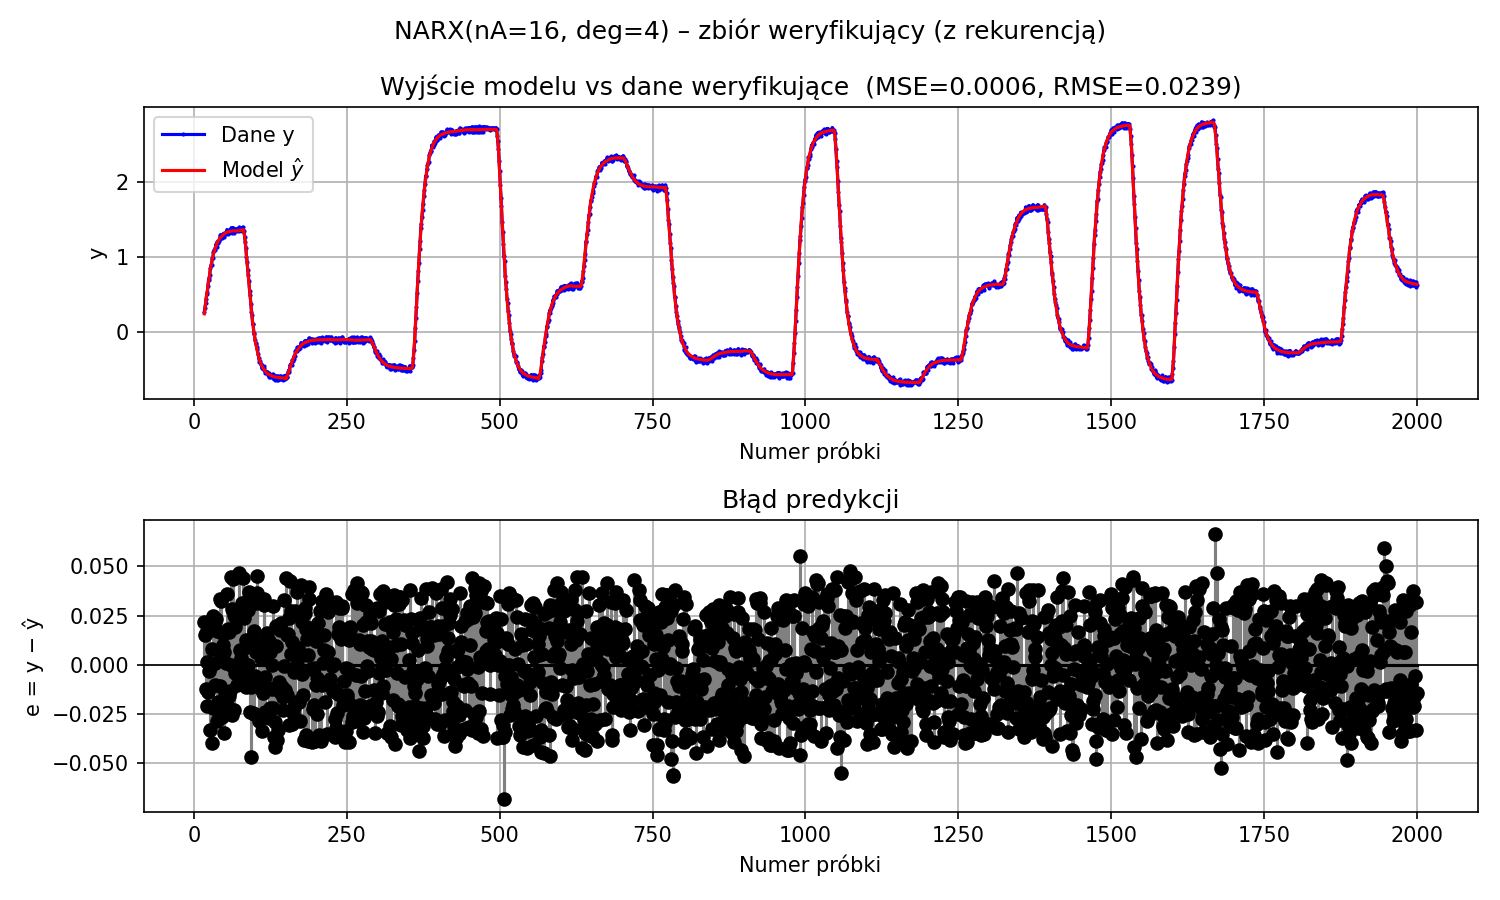

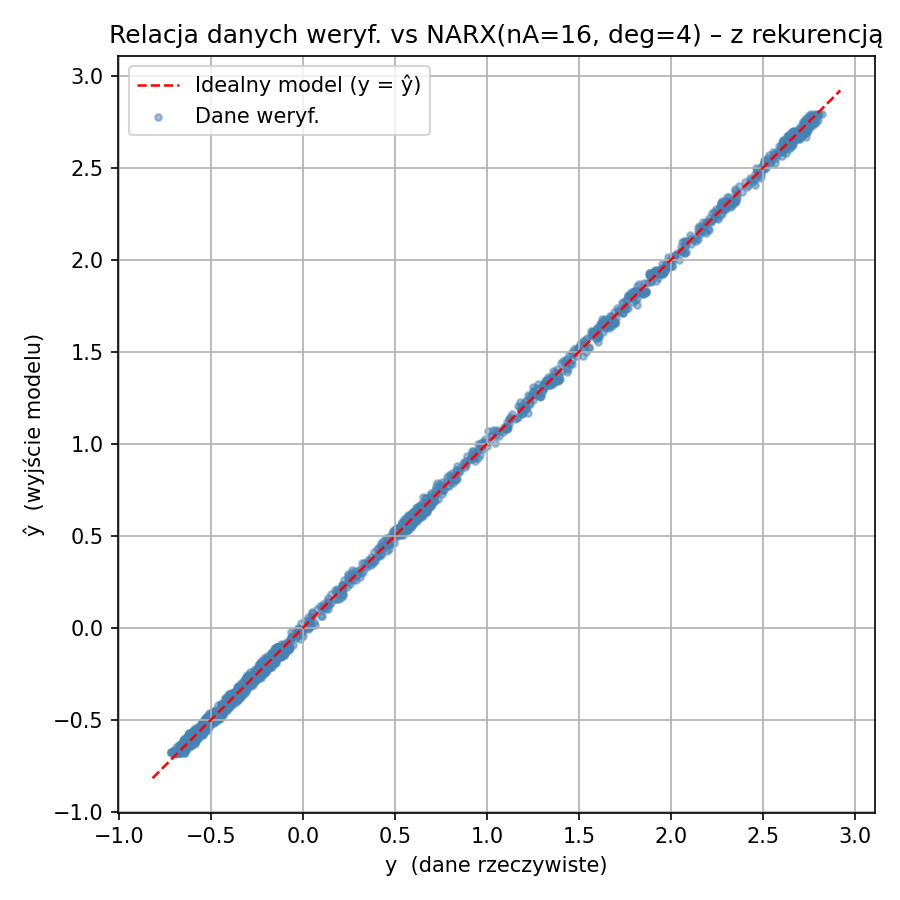

In [16]:
display_png("identyfikacja_modeli_dynamicznych/obrazki/modele_narx/tabela_metryk_narx.png", width=1200)

best_nA = int(best_narx["nA"])
best_deg = int(best_narx["deg"])
display(Markdown(f"### Wykresy najlepszego modelu NARX w trybie rekurencyjnym: nA=nB={best_nA}, d={best_deg}"))
display_png(f"identyfikacja_modeli_dynamicznych/obrazki/modele_narx/nA{best_nA}_deg{best_deg}/nA{best_nA}_deg{best_deg}_r_weryfikacja.png")
display_png(f"identyfikacja_modeli_dynamicznych/obrazki/modele_narx/nA{best_nA}_deg{best_deg}/nA{best_nA}_deg{best_deg}_r_scatter.png", width=620)

**Wybór modelu nieliniowego:** jako kryterium podstawowe przyjęto najmniejsze MSE weryfikacyjne w trybie rekurencyjnym. Jeżeli dwa modele mają bardzo zbliżone błędy, praktycznie korzystniejszy jest model o mniejszej liczbie parametrów, bo jest mniej podatny na przeuczenie i łatwiejszy do interpretacji.

## 2d. Charakterystyka statyczna z modelu NARX

Charakterystykę statyczną najlepszego modelu NARX wyznaczono metodą symulacyjną. Dla stałego wejścia $u^*$ uruchomiono model rekurencyjnie przez wiele próbek, a ostatnią wartość $\hat{y}$ potraktowano jako stan ustalony.

u*,y statyczne,y NARX,|błąd|
-0.846223,0.776698,0.847879,0.071180
-0.097748,-0.357367,-0.288268,0.069098
0.855879,2.819566,2.871001,0.051434


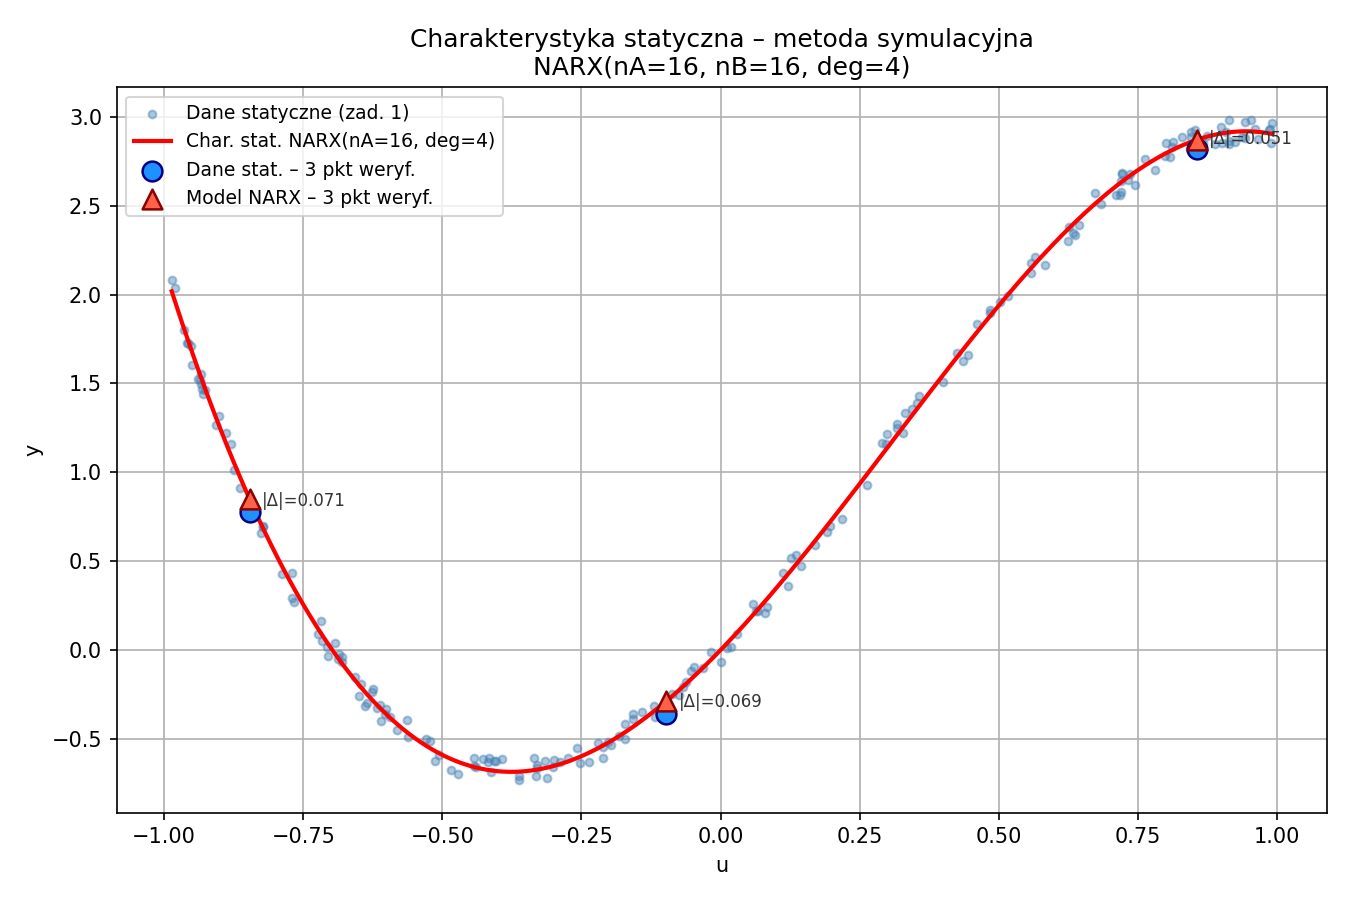

In [17]:
def simulate_static_narx(model, u_star: float, n_sim: int = 600) -> float:
    u = np.full(n_sim, u_star)
    y_hat, _ = model.predict(u, np.zeros(n_sim), recursive=True)
    value = float(y_hat[-1])
    return value if np.isfinite(value) else np.nan


stat_data = np.loadtxt(ROOT / "danestat28" / "danestat28.txt")
u_stat = stat_data[:, 0]
y_stat = stat_data[:, 1]

u_curve = np.linspace(u_stat.min(), u_stat.max(), 200)
y_curve = np.array([simulate_static_narx(best_narx["model"], u) for u in u_curve])

q_vals = [np.percentile(u_stat, p) for p in [10, 50, 90]]
pts_idx = [int(np.argmin(np.abs(u_stat - q))) for q in q_vals]
u_pts = u_stat[pts_idx]
y_pts_data = y_stat[pts_idx]
y_pts_model = np.array([simulate_static_narx(best_narx["model"], u) for u in u_pts])

static_check_rows = []
for u_val, y_data, y_model in zip(u_pts, y_pts_data, y_pts_model):
    static_check_rows.append({
        "u": u_val,
        "y_data": y_data,
        "y_model": y_model,
        "abs_error": abs(y_data - y_model),
    })

show_table(static_check_rows, [
    ("u", "u*"), ("y_data", "y statyczne"), ("y_model", "y NARX"), ("abs_error", "|błąd|"),
], "Porównanie charakterystyki statycznej w 3 punktach")

# Wygeneruj dodatkowy wykres dla najlepszego modelu wybranego w tej sesji notebooka.
best_nA = int(best_narx["nA"])
best_deg = int(best_narx["deg"])
plotter_dyn.plot_static_characteristic_narx(
    u_curve, y_curve, u_stat, y_stat,
    u_pts, y_pts_data, y_pts_model,
    best_nA, best_deg,
)

display_png(f"identyfikacja_modeli_dynamicznych/obrazki/modele_narx/charakterystyka_statyczna_nA{best_nA}_deg{best_deg}.png", width=800)

# Wnioski końcowe

1. Model liniowy jest użytecznym punktem odniesienia, ale w części statycznej dokładniejsze wyniki daje model wielomianowy dobrany na podstawie błędu weryfikacyjnego.
2. W modelach dynamicznych ocena rekurencyjna jest surowsza od predykcji bez rekurencji, bo błędy modelu wpływają na kolejne próbki.
3. Najlepszy model NARX dobrany według MSE weryfikacyjnego w trybie rekurencyjnym najlepiej nadaje się do dalszej symulacji i do wyznaczenia charakterystyki statycznej metodą symulacyjną.
4. Zgodność charakterystyki statycznej NARX z danymi statycznymi należy oceniać nie tylko po trzech punktach kontrolnych, ale też po kształcie całej krzywej względem chmury danych.

---

## 3. Identyfikacja modelem neuronowym (Keras)

Statyczny model neuronowy z **jedną warstwą ukrytą**:

$$\hat{y}(u) = \sum_{j=1}^{H} v_j \cdot \tanh\!\Bigl(\sum_{i=1}^{1} w_{ji}\,u + b_j^{(1)}\Bigr) + b^{(2)},$$

gdzie $H$ – liczba neuronów ukrytych. Wagi uczone metodą minimalizacji MSE algorytmem wstecznej propagacji błędu.

Rozważono trzy przypadki:

| Przypadek | Neurony ukryte | Liczba parametrów |
|---|---|---|
| Zbyt mała | 1 | 4 |
| Umiarkowana | 10 | 31 |
| Zbyt duża | 500 | 1 501 |

Dla każdego przypadku uczenie powtórzono przy zmianach:
- **algorytmu optymalizacji**: Adam, SGD, RMSprop (przy lr = 0,01 i stałym punkcie startowym),
- **współczynnika uczenia**: 0,001 / 0,01 / 0,1 (przy Adam i stałym punkcie startowym),
- **punktu startowego wag**: seed = 42 / 123 / 999 (przy Adam i lr = 0,01).

Backend Keras: PyTorch (TensorFlow nie wspiera Pythona 3.14).

In [18]:
import os
os.environ.setdefault('KERAS_BACKEND', 'torch')

# Ścieżki do kodu i obrazków modeli neuronowych
NEURAL_CODE = ROOT / "identyfikcja_modelem_neuronowym" / "model_Keras" / "kod"
NEURAL_IMG  = ROOT / "identyfikcja_modelem_neuronowym" / "model_Keras" / "obrazki"

# Moduły bez zależności od Keras (import_danych, rysowanie)
neural_import   = load_module("modi_neural_import",   NEURAL_CODE / "import_danych.py")
neural_plotting = load_module("modi_neural_plotting",  NEURAL_CODE / "rysowanie.py")
# neural_models (wymaga Keras) ładowany osobno w komórce RUN_NEURAL

print(f"Obrazki: {NEURAL_IMG}")

# Konfiguracja eksperymentów (musi być spójna z main.py)
NN_HIDDEN_SIZES = {'zbyt_mala': 1, 'umiarkowana': 10, 'zbyt_duza': 500}
NN_OPTIMIZERS   = ['adam', 'sgd', 'rmsprop']
NN_LR_LIST      = [0.001, 0.01, 0.1]
NN_SEEDS        = [42, 123, 999]
NN_FIX_OPT      = 'adam'
NN_FIX_LR       = 0.01
NN_FIX_SEED     = 42
NN_EPOCHS       = {'zbyt_mala': 8000, 'umiarkowana': 4000, 'zbyt_duza': 1500}
NN_BATCH_SIZE   = 32


Obrazki: C:\Users\mikol\OneDrive\Politechnika\MODI\Projekt2\identyfikcja_modelem_neuronowym\model_Keras\obrazki


In [19]:
RUN_NEURAL = False  # True = przelicz od nowa (wolne, ~27 modeli); False = wczytaj z PNG

if RUN_NEURAL:
    # Keras potrzebne tylko przy uczeniu
    neural_models = load_module("modi_neural_models", NEURAL_CODE / "modele_neuronowe.py")
    dane_nn   = neural_import.ImportStaticData(split=0.6)
    plotter_nn = neural_plotting.PlotNeural(str(NEURAL_IMG))

    def _run_experiment(n_hidden, optimizer_name, lr, seed, size_label):
        epochs = NN_EPOCHS[size_label]
        model = neural_models.KerasNNModel(
            n_hidden=n_hidden, optimizer_name=optimizer_name, lr=lr, seed=seed
        )
        model.fit(dane_nn.u_ucz, dane_nn.y_ucz,
                  epochs=epochs, batch_size=NN_BATCH_SIZE, verbose=0)
        res_ucz = model.evaluate(dane_nn.u_ucz, dane_nn.y_ucz)
        res_wer = model.evaluate(dane_nn.u_wer, dane_nn.y_wer)
        u_curve = np.linspace(dane_nn.u.min(), dane_nn.u.max(), 300)
        y_curve = model.predict(u_curve)
        return {
            'model': model,
            'n_hidden': n_hidden, 'optimizer': optimizer_name, 'lr': lr, 'seed': seed,
            'n_params': model.n_params,
            'mse_ucz': res_ucz['mse'], 'rmse_ucz': res_ucz['rmse'],
            'mse_wer': res_wer['mse'], 'rmse_wer': res_wer['rmse'],
            'y_pred_ucz': res_ucz['y_pred'], 'y_pred_wer': res_wer['y_pred'],
            'u_curve': u_curve, 'y_curve': y_curve,
            'history_loss': model.history_loss,
            'label': f"opt={optimizer_name}, lr={lr}, seed={seed}",
        }

    nn_all_results = {}
    for size_label, n_hidden in NN_HIDDEN_SIZES.items():
        print(f"\nUczę sieć: {size_label} (hidden={n_hidden}) ...")
        all_exp = []
        for opt in NN_OPTIMIZERS:
            print(f"  opt={opt}, lr={NN_FIX_LR}, seed={NN_FIX_SEED}")
            all_exp.append(_run_experiment(n_hidden, opt, NN_FIX_LR, NN_FIX_SEED, size_label))
        for lr in NN_LR_LIST:
            print(f"  opt={NN_FIX_OPT}, lr={lr}, seed={NN_FIX_SEED}")
            r = _run_experiment(n_hidden, NN_FIX_OPT, lr, NN_FIX_SEED, size_label)
            if not any(x['optimizer'] == NN_FIX_OPT and x['lr'] == lr and x['seed'] == NN_FIX_SEED
                       for x in all_exp):
                all_exp.append(r)
        for seed in NN_SEEDS:
            print(f"  opt={NN_FIX_OPT}, lr={NN_FIX_LR}, seed={seed}")
            r = _run_experiment(n_hidden, NN_FIX_OPT, NN_FIX_LR, seed, size_label)
            if not any(x['optimizer'] == NN_FIX_OPT and x['lr'] == NN_FIX_LR and x['seed'] == seed
                       for x in all_exp):
                all_exp.append(r)
        nn_all_results[size_label] = all_exp

        group_opt  = [r for r in all_exp if r['lr'] == NN_FIX_LR and r['seed'] == NN_FIX_SEED
                      and r['optimizer'] in NN_OPTIMIZERS]
        group_lr   = [r for r in all_exp if r['optimizer'] == NN_FIX_OPT and r['seed'] == NN_FIX_SEED]
        group_seed = [r for r in all_exp if r['optimizer'] == NN_FIX_OPT and r['lr'] == NN_FIX_LR]
        plotter_nn.plot_learning_curves(
            group_opt,  f"Krzywe uczenia – {size_label} | zmiana optymalizatora",
            'krzywe_opt.png',  size_label)
        plotter_nn.plot_learning_curves(
            group_lr,   f"Krzywe uczenia – {size_label} | zmiana LR",
            'krzywe_lr.png',   size_label)
        plotter_nn.plot_learning_curves(
            group_seed, f"Krzywe uczenia – {size_label} | zmiana punktu startowego",
            'krzywe_seed.png', size_label)
        best = min(all_exp, key=lambda r: r['mse_wer'])
        plotter_nn.plot_characteristic_curve(
            dane_nn.u, dane_nn.y, dane_nn.u_ucz, dane_nn.y_ucz,
            dane_nn.u_wer, dane_nn.y_wer, best['u_curve'], best['y_curve'],
            str(best['model']), best['mse_ucz'], best['mse_wer'],
            'charakterystyka_best.png', size_label
        )
    plotter_nn.plot_mse_comparison(
        {sl: [{'label': r['label'], 'mse_ucz': r['mse_ucz'], 'mse_wer': r['mse_wer']} for r in rs]
         for sl, rs in nn_all_results.items()}
    )
    print("\nWszystkie wykresy zapisane.")
else:
    display(Markdown(
        "Obliczenia wykonano wcześniej (skrypt `main.py`). "
        "Poniżej wyświetlane są wygenerowane rysunki PNG.  \n"
        "Aby przeliczyć ponownie, zmień `RUN_NEURAL = True`."
    ))


Obliczenia wykonano wcześniej (skrypt `main.py`). Poniżej wyświetlane są wygenerowane rysunki PNG.  
Aby przeliczyć ponownie, zmień `RUN_NEURAL = True`.

### 3a. Sieć zbyt mała (1 neuron ukryty)

Sieć z jednym neuronem ukrytym ma tylko **4 parametry**. Funkcja $\tanh$ daje krzywą sigmoidalną – model nie jest w stanie odwzorować złożonej charakterystyki statycznej.

**Zmiana optymalizatora** (lr=0.01, seed=42)

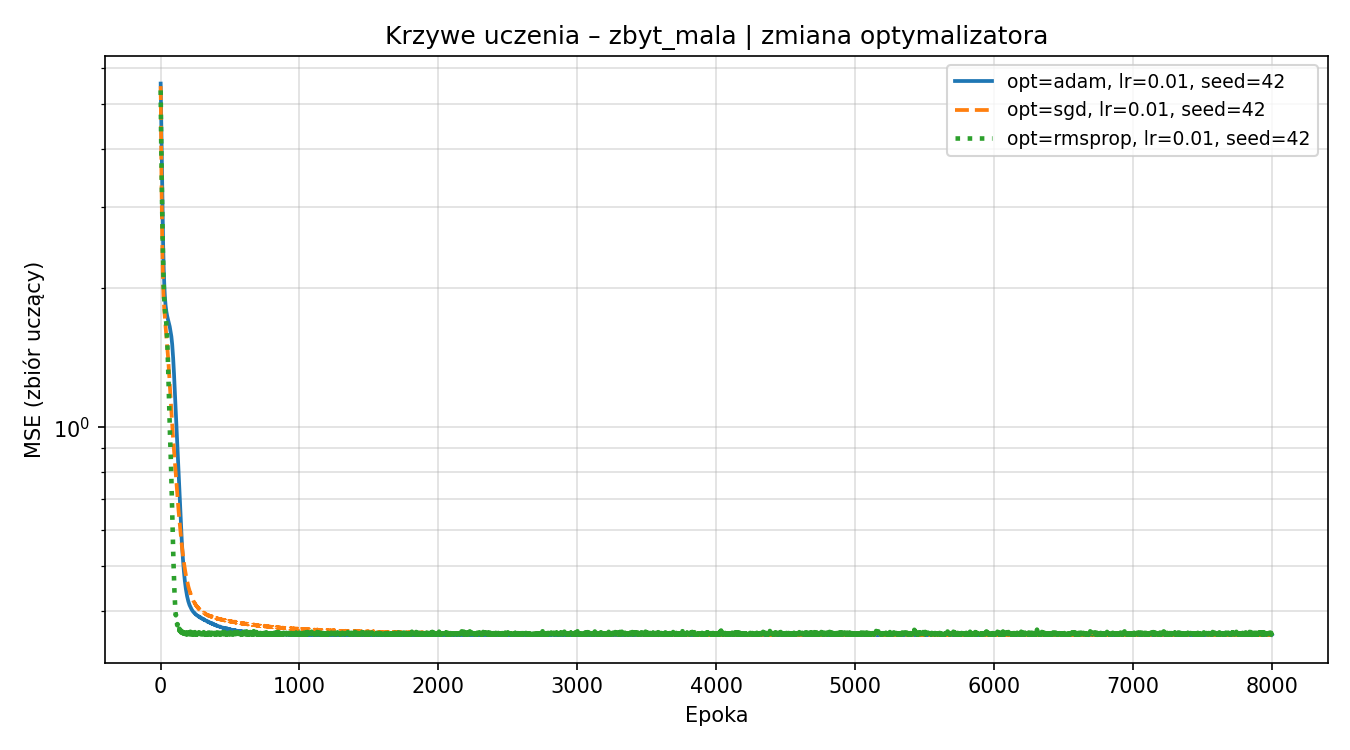

**Zmiana współczynnika uczenia** (Adam, seed=42)

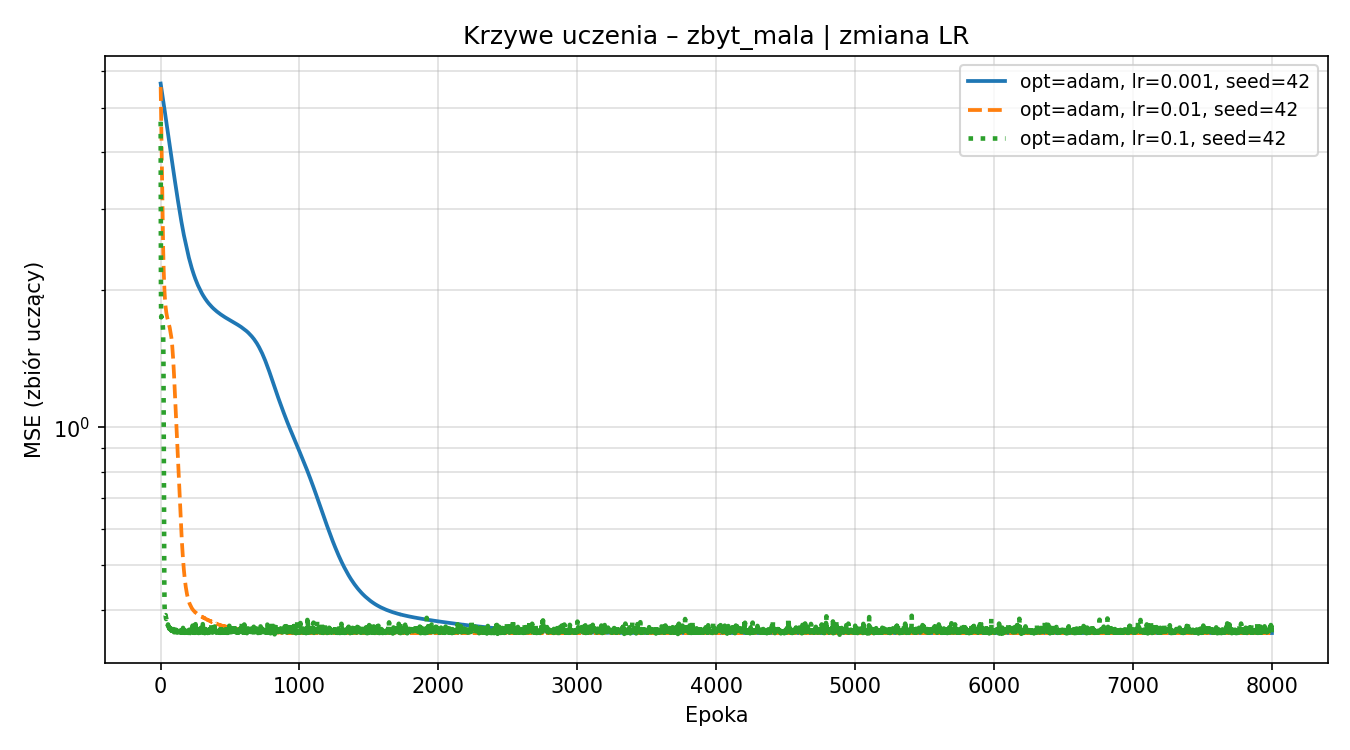

**Zmiana punktu startowego** (Adam, lr=0.01)

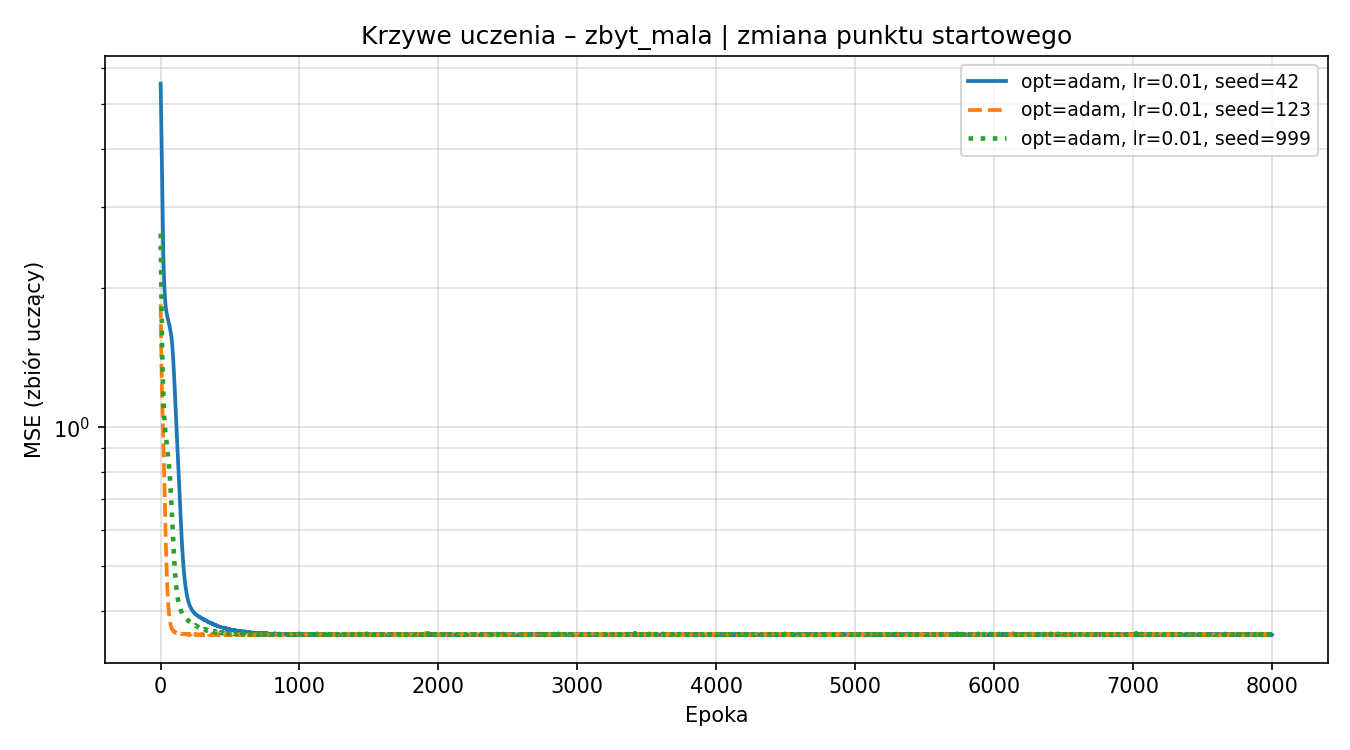

**Charakterystyka statyczna – najlepszy model**

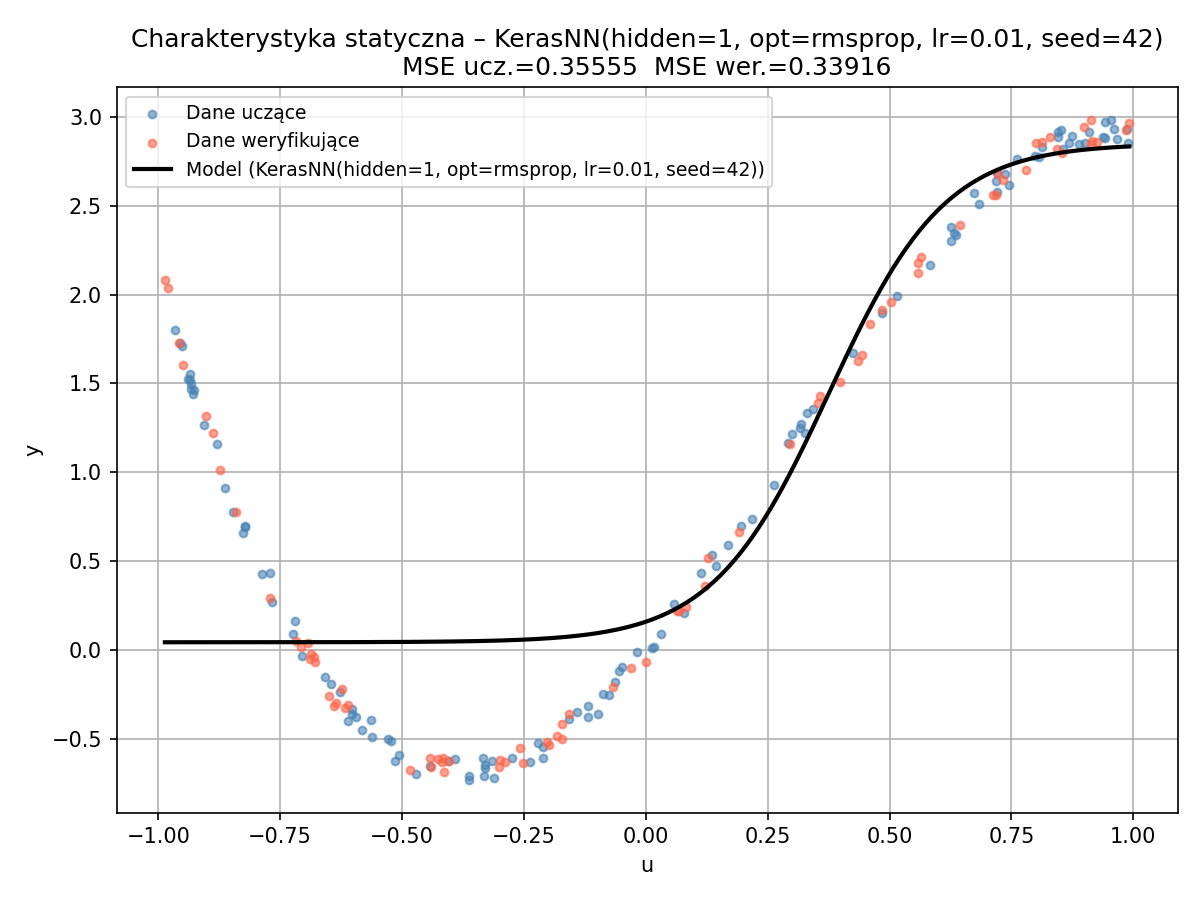

In [20]:
_sz = 'zbyt_mala'
display(Markdown("**Zmiana optymalizatora** (lr=0.01, seed=42)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_opt.png")
display(Markdown("**Zmiana współczynnika uczenia** (Adam, seed=42)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_lr.png")
display(Markdown("**Zmiana punktu startowego** (Adam, lr=0.01)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_seed.png")
display(Markdown("**Charakterystyka statyczna – najlepszy model**"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/charakterystyka_best.png")

### 3b. Sieć umiarkowana (10 neuronów ukrytych)

Sieć z 10 neuronami ukrytymi ma **31 parametrów**. Powinna być wystarczająco elastyczna do aproksymacji statycznej charakterystyki, przy jednoczesnym braku wyraźnego przeuczenia.

**Zmiana optymalizatora** (lr=0.01, seed=42)

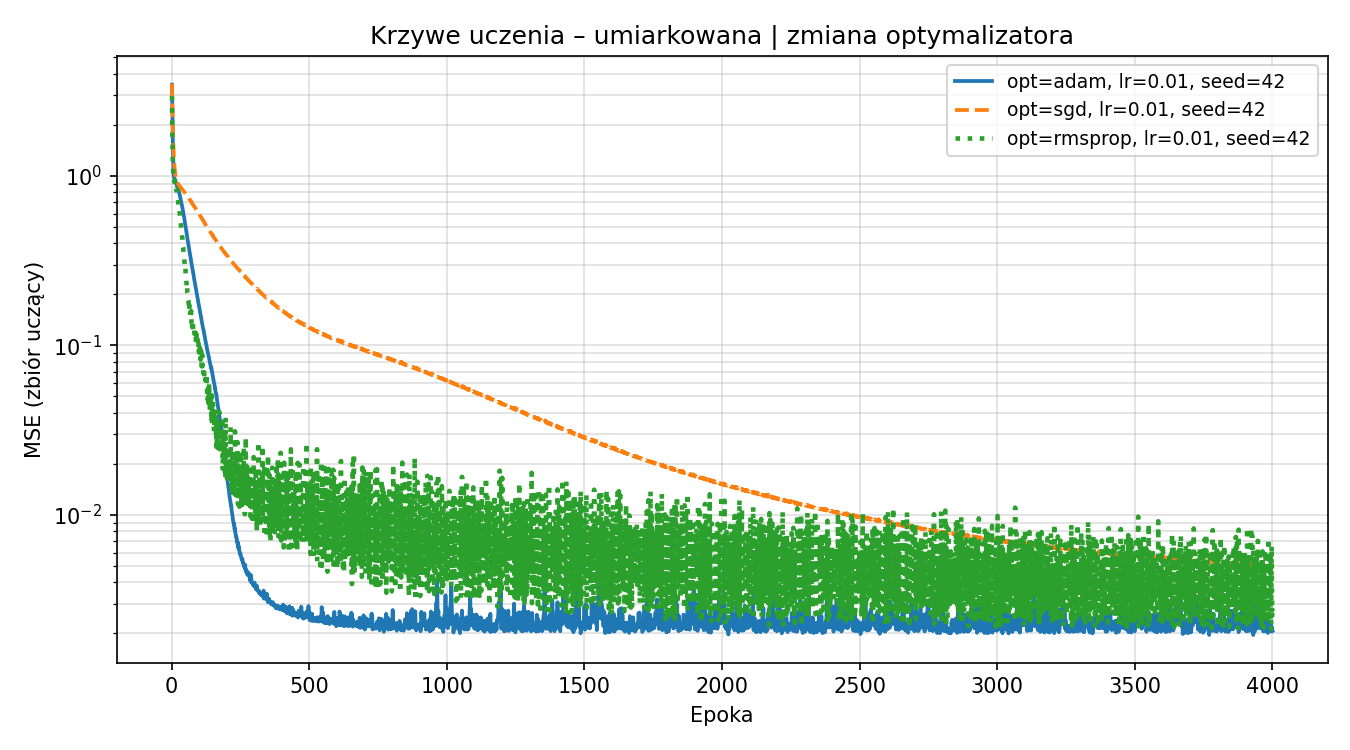

**Zmiana współczynnika uczenia** (Adam, seed=42)

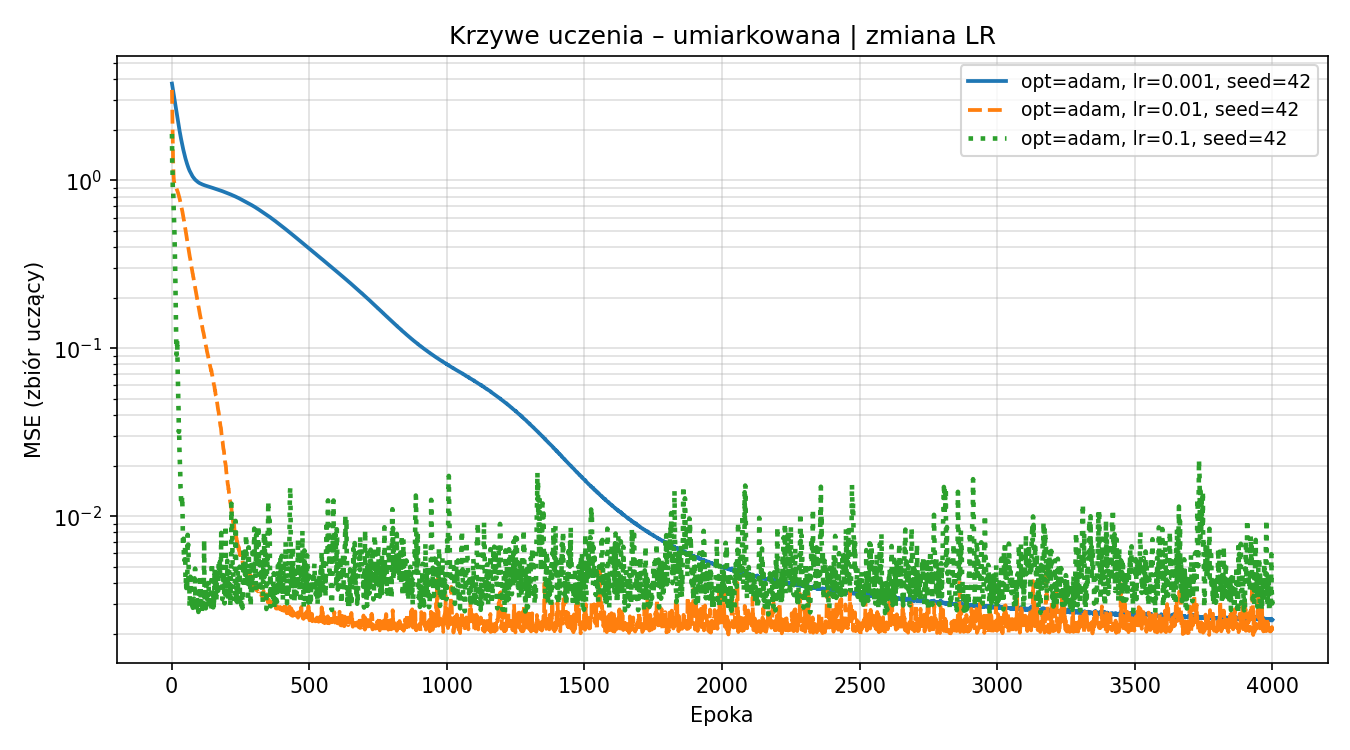

**Zmiana punktu startowego** (Adam, lr=0.01)

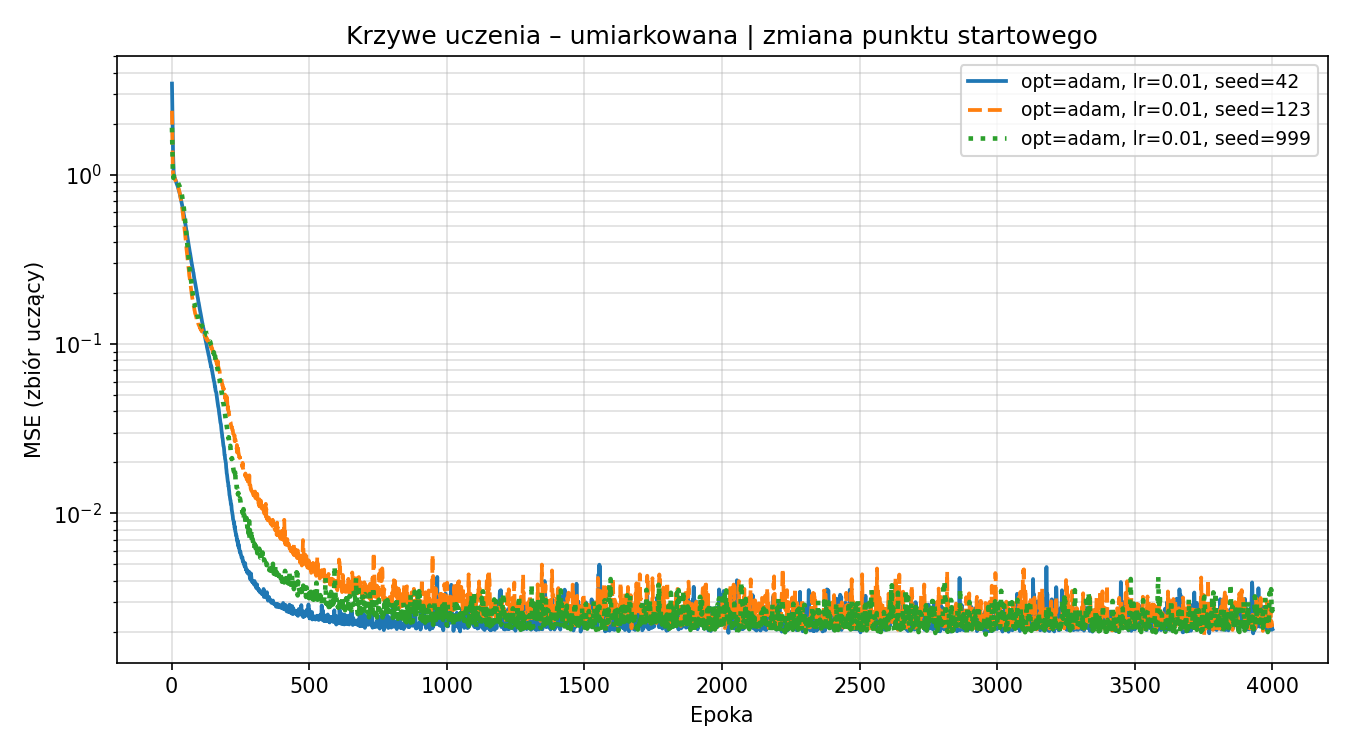

**Charakterystyka statyczna – najlepszy model**

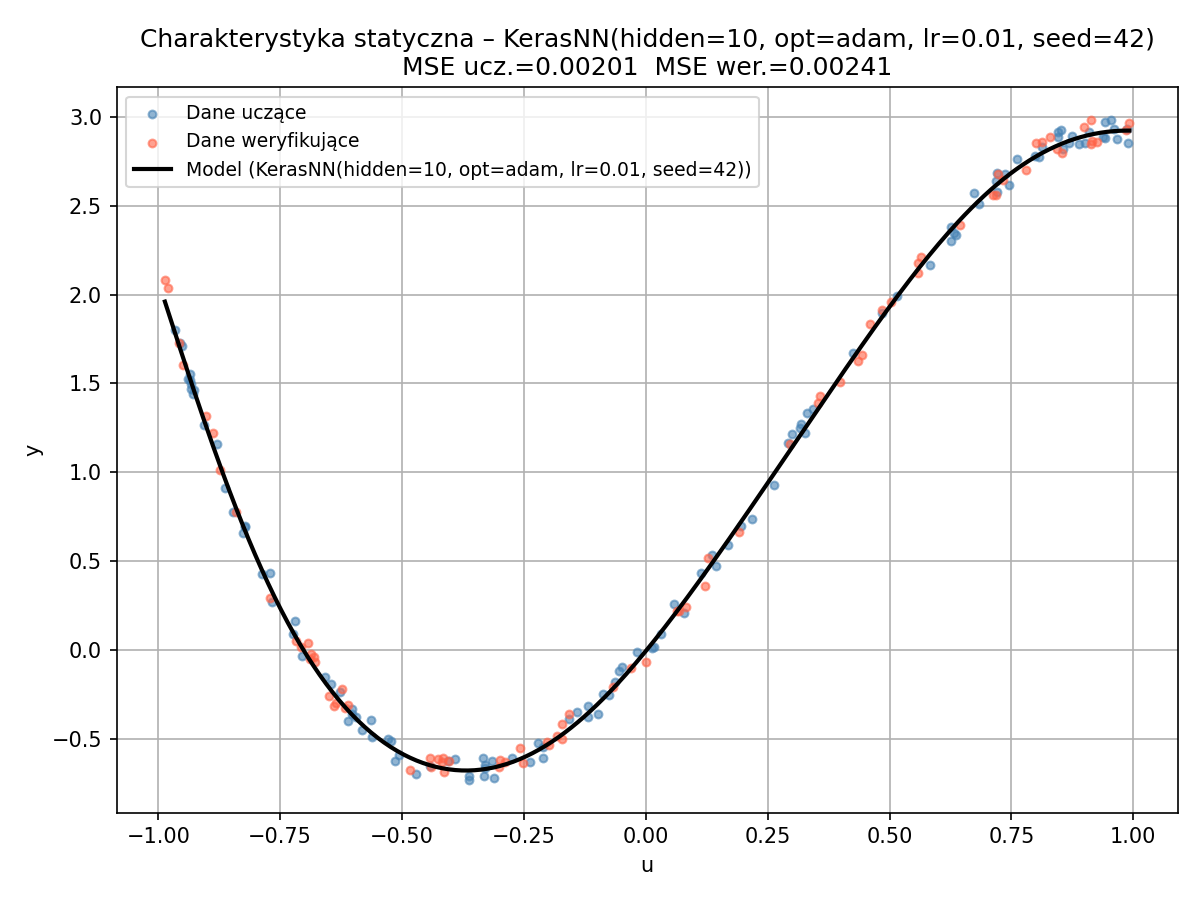

In [21]:
_sz = 'umiarkowana'
display(Markdown("**Zmiana optymalizatora** (lr=0.01, seed=42)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_opt.png")
display(Markdown("**Zmiana współczynnika uczenia** (Adam, seed=42)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_lr.png")
display(Markdown("**Zmiana punktu startowego** (Adam, lr=0.01)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_seed.png")
display(Markdown("**Charakterystyka statyczna – najlepszy model**"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/charakterystyka_best.png")

### 3c. Sieć zbyt duża (500 neuronów ukrytych)

Sieć z 500 neuronami ukrytymi ma **1 501 parametrów** – ponad 12-krotnie więcej niż danych uczących. Oczekuje się przeuczenia: MSE uczący będzie bardzo niski, ale MSE weryfikujący może wzrosnąć.

**Zmiana optymalizatora** (lr=0.01, seed=42)

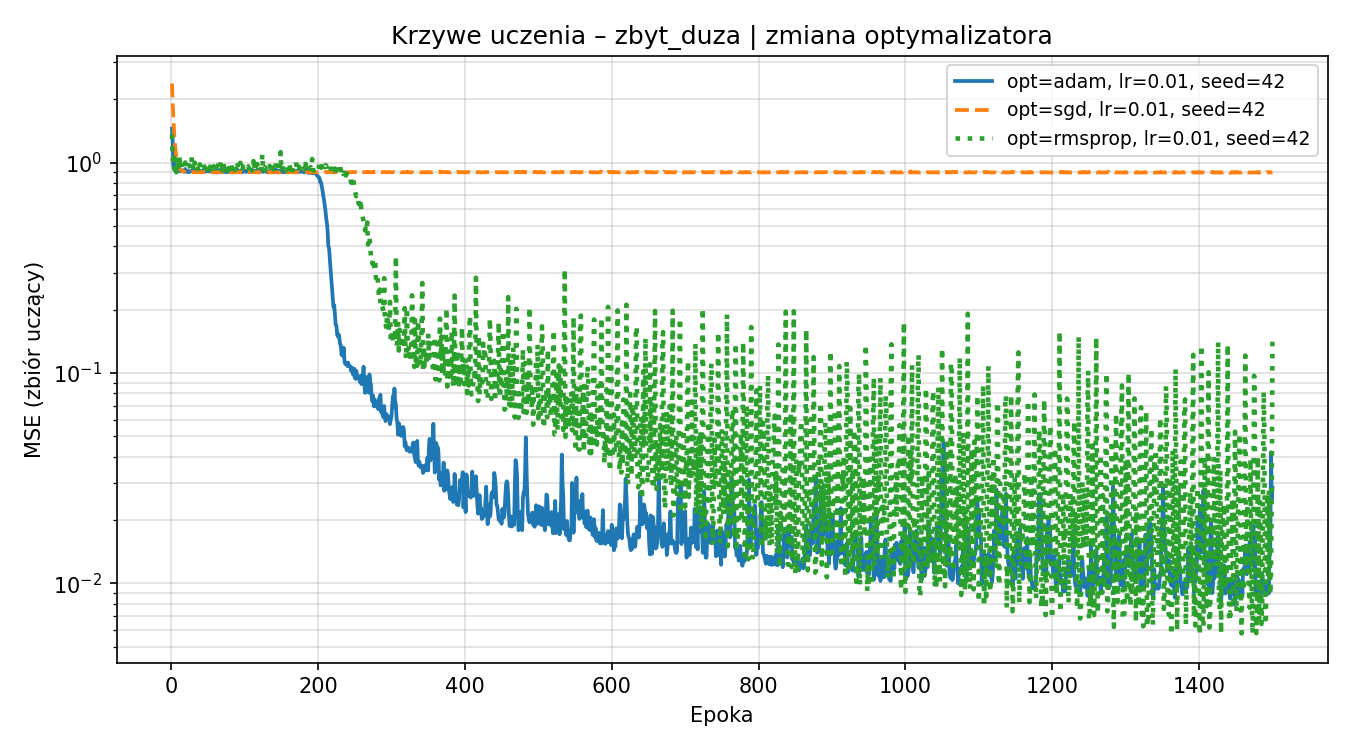

**Zmiana współczynnika uczenia** (Adam, seed=42)

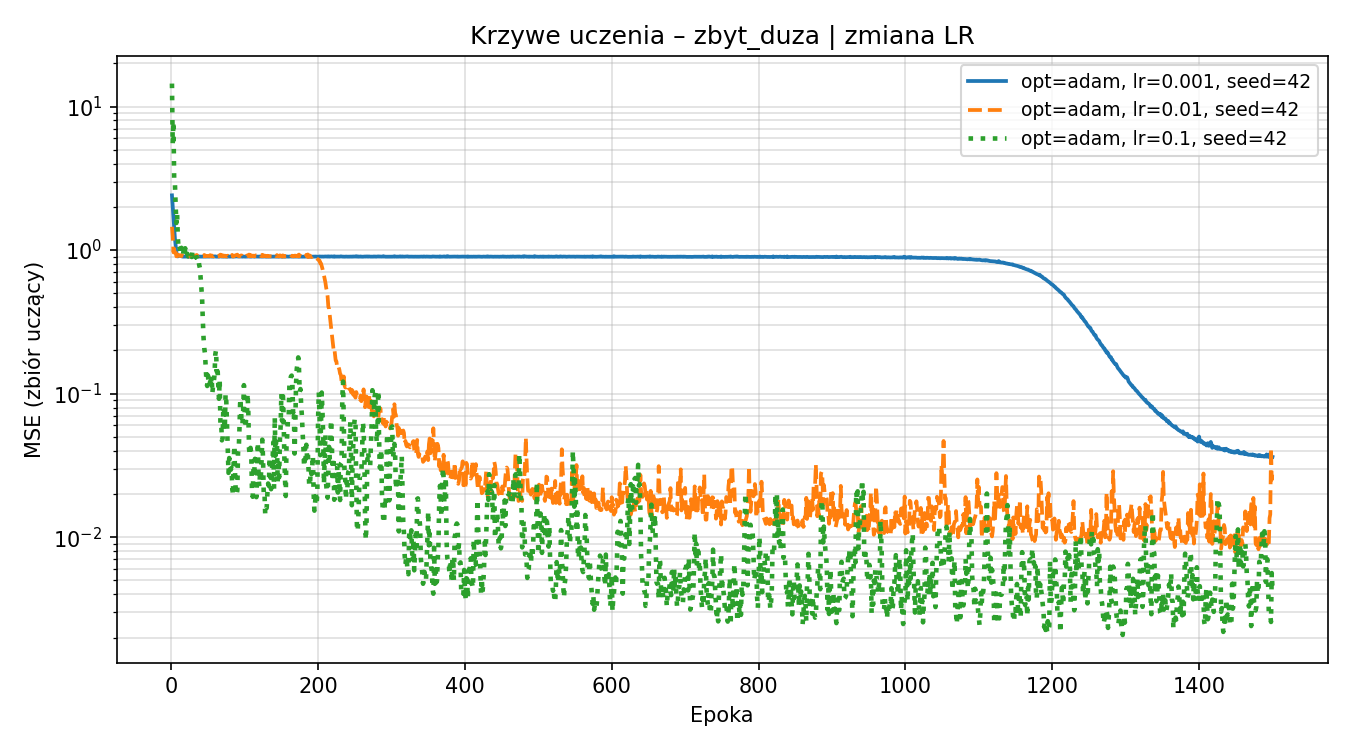

**Zmiana punktu startowego** (Adam, lr=0.01)

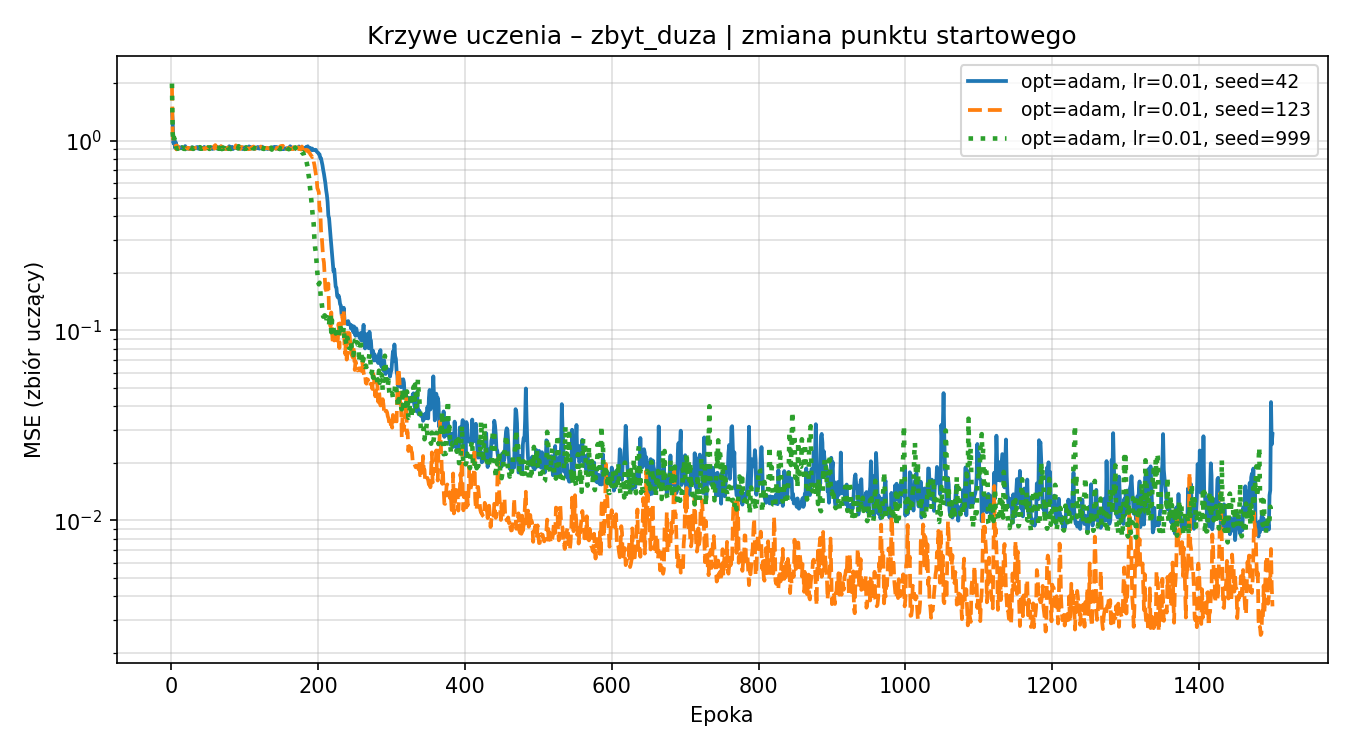

**Charakterystyka statyczna – najlepszy model**

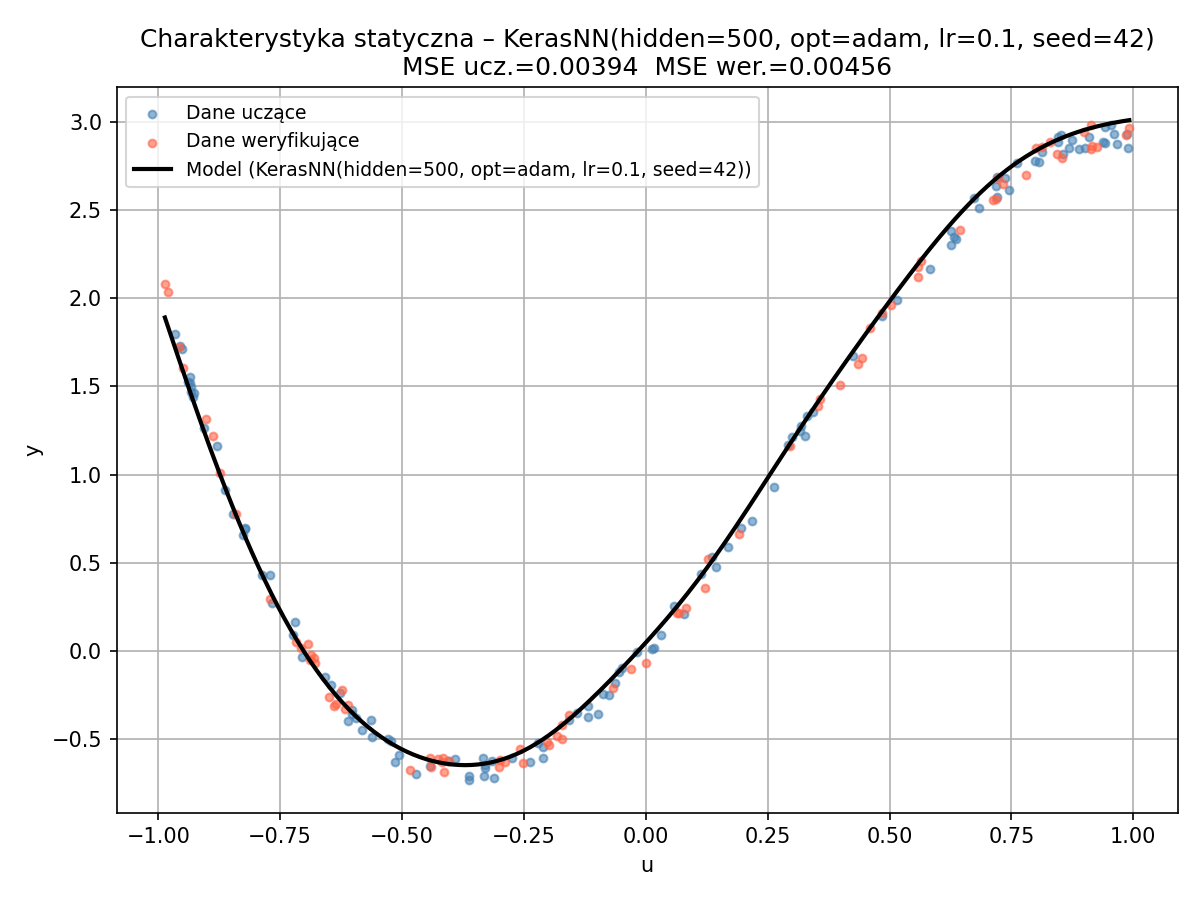

In [22]:
_sz = 'zbyt_duza'
display(Markdown("**Zmiana optymalizatora** (lr=0.01, seed=42)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_opt.png")
display(Markdown("**Zmiana współczynnika uczenia** (Adam, seed=42)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_lr.png")
display(Markdown("**Zmiana punktu startowego** (Adam, lr=0.01)"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/krzywe_seed.png")
display(Markdown("**Charakterystyka statyczna – najlepszy model**"))
display_png(f"identyfikcja_modelem_neuronowym/model_Keras/obrazki/{_sz}/charakterystyka_best.png")

### 3d. Zestawienie wyników

**Porównanie MSE najlepszych modeli każdego rozmiaru**

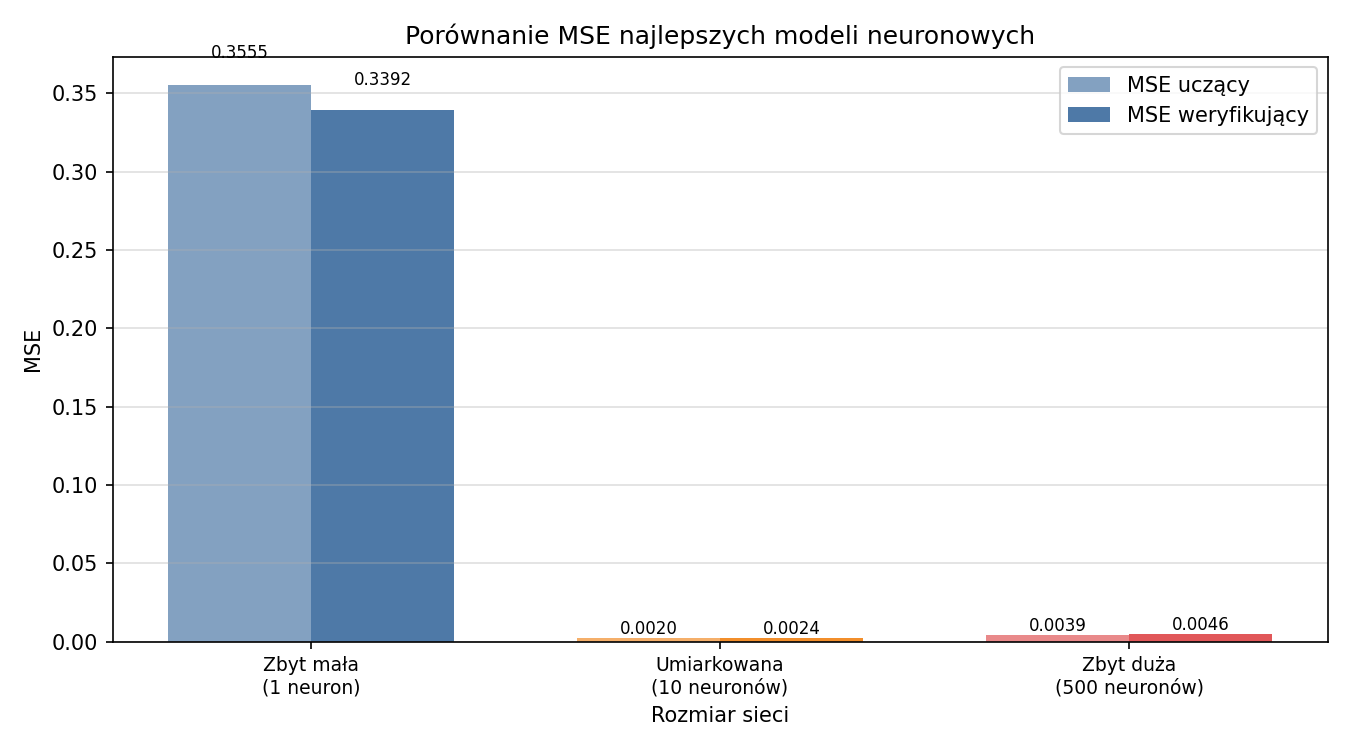

_Tabela dostępna po uruchomieniu z `RUN_NEURAL = True`._

In [23]:
display(Markdown("**Porównanie MSE najlepszych modeli każdego rozmiaru**"))
display_png("identyfikcja_modelem_neuronowym/model_Keras/obrazki/porownanie_mse.png")

# Zbiorcza tabela z wynikami (wczytaj z pliku wynikowego main.py lub wyświetl ręcznie po RUN_NEURAL)
if 'nn_all_results' in dir():
    rows = []
    for size_label, exp_list in nn_all_results.items():
        for r in exp_list:
            rows.append({
                'size': size_label, 'hidden': r['n_hidden'],
                'opt': r['optimizer'], 'lr': r['lr'], 'seed': r['seed'],
                'params': r['n_params'],
                'mse_ucz': r['mse_ucz'], 'rmse_ucz': r['rmse_ucz'],
                'mse_wer': r['mse_wer'], 'rmse_wer': r['rmse_wer'],
            })
    show_table(rows, [
        ('size',    'Rozmiar'), ('hidden', 'Ukryte'), ('opt', 'Optymalizator'),
        ('lr',      'LR'),      ('seed',  'Seed'),    ('params', 'L. par.'),
        ('mse_ucz', 'MSE ucz.'), ('rmse_ucz', 'RMSE ucz.'),
        ('mse_wer', 'MSE wer.'), ('rmse_wer', 'RMSE wer.'),
    ], title='Wyniki identyfikacji modelem neuronowym (Keras)', precision=5)
else:
    display(Markdown(
        "_Tabela dostępna po uruchomieniu z `RUN_NEURAL = True`._"
    ))

### 3e. Omówienie wyników

**Sieć zbyt mała (1 neuron, 4 par.):**  
Jeden neuron z $\tanh$ może odwzorować jedynie monotoniczne krzywą sigmoidalną. Jeżeli charakterystyka statyczna jest bardziej złożona, sieć nie jest w stanie dobrze dopasować danych – MSE weryfikacyjny pozostaje wysoki dla wszystkich optymalizatorów, współczynników uczenia i punktów startowych. Wynik jest mało wrażliwy na wybór algorytmu i punktu startowego, bo obszar rozwiązań jest bardzo ubogi.

**Sieć umiarkowana (10 neuronów, 31 par.):**  
Sieć ma wystarczającą pojemność do aproksymacji nielinearności. Kluczowe obserwacje:
- **Wpływ optymalizatora:** Adam i RMSprop zazwyczaj schodziły szybciej niż SGD; przy tym samym lr SGD wymaga więcej epok lub wyższego lr.
- **Wpływ lr:** Zbyt małe lr (0,001) prowadzi do wolnej zbieżności w 4000 epokach. Zbyt duże lr (0,1) może powodować oscylacje lub zatrzymanie w lokalnym minimum. Optymalny zakres to lr ≈ 0,01.
- **Wpływ punktu startowego:** Przy umiarkowanej sieci dobry optymalizator i odpowiedni lr prowadzą do podobnych wyników niezależnie od startu (stabilna zbieżność), choć mogą wystąpić lokalne minima.

**Sieć zbyt duża (500 neuronów, 1 501 par.):**  
Liczba parametrów przekracza 12-krotnie liczbę danych uczących. Sieć może **zapamiętać** dane zamiast nauczyć się ich wzorca:
- MSE uczący jest bardzo niski (bliski zera przy wystarczającej liczbie epok),
- MSE weryfikujący może być wyraźnie wyższy niż dla sieci umiarkowanej – to **przeuczenie** (*overfitting*).
- Różne punkty startowe prowadzą do bardziej rozproszonych wyników, bo przestrzeń wag jest ogromna.

**Ogólne wnioski:**
1. Dla tego zadania (statyczna identyfikacja) sieć z 10 neuronami jest rozsądnym wyborem.
2. Algorytm Adam z lr ≈ 0,01 zapewnia najszybszą i najbardziej niezawodną zbieżność.
3. Modele neuronowe osiągają niższe MSE weryfikacyjne niż model liniowy, zbliżone do modelu wielomianowego wyższego stopnia, ale bez ryzyka "wibracji" na krańcach przedziału.
4. Porównując z NARX: statyczny model neuronowy aproksymuje tylko charakterystykę $y(u)$, natomiast NARX modeluje pełną dynamikę – cel jest inny.

## Pliki źródłowe do dołączenia

Do archiwum oddawanego w systemie Studia należy dołączyć PDF sprawozdania oraz pliki `.py` z katalogów:

- `indetyfikacja_modeli_statycznych/kod/`
- `identyfikacja_modeli_dynamicznych/kod/`

Nie trzeba dołączać plików graficznych, ponieważ notebook i skrypty generują je ponownie.